In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import shap
import matplotlib.pyplot as plt
from scipy import stats
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split,StratifiedKFold,RandomizedSearchCV
from sklearn.metrics import (accuracy_score,classification_report,confusion_matrix,roc_auc_score,
                            precision_score,recall_score,f1_score,average_precision_score,
                            precision_recall_curve)
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.preprocessing import RobustScaler
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import KNNImputer
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier,AdaBoostClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier

%matplotlib inline

c:\Users\prath\Downloads\Churn Prediction\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
df=pd.read_csv('C:\\Users\\prath\\Downloads\\Churn Prediction\\Data\\cleaned_data.csv')

In [3]:
df['Product usage hours(3m)']=df['Product usage hours(3m)'].where(df['Product usage hours(3m)']>=0,np.nan)
df['Product usage hours(12m)']=df['Product usage hours(12m)'].where(df['Product usage hours(12m)']>=0,np.nan)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 39 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Unnamed: 0                  50000 non-null  int64  
 1   Industry                    43501 non-null  object 
 2   Sub Industry                34032 non-null  object 
 3   Region                      42481 non-null  object 
 4   Company size                39957 non-null  float64
 5   Annual revenue(USD)         43293 non-null  float64
 6   Contract value(USD)         37265 non-null  float64
 7   Contract length(m)          39007 non-null  float64
 8   Product usage hours(3m)     41239 non-null  float64
 9   Product usage hours(12m)    45440 non-null  float64
 10  Login frequency(30d)        47172 non-null  float64
 11  Active users                43536 non-null  float64
 12  Licensed users              34551 non-null  float64
 13  Analyst calls(6m)           400

In [6]:
df['Region'].unique()

array(['North America', 'Europe', 'Latam', nan, 'Middle East', 'Apac'],
      dtype=object)

In [4]:
df.columns

Index(['Unnamed: 0', 'Industry', 'Sub Industry', 'Region', 'Company size',
       'Annual revenue(USD)', 'Contract value(USD)', 'Contract length(m)',
       'Product usage hours(3m)', 'Product usage hours(12m)',
       'Login frequency(30d)', 'Active users', 'Licensed users',
       'Analyst calls(6m)', 'Support tickets(6m)', 'Support escalations(6m)',
       'Avg resolution time(hrs)', 'Nps score', 'Survey response count(12m)',
       'Discount', 'Account notes', 'Churn flag', 'Tenure(d)',
       'missing_discount', 'missing_licensed_users', 'missing_avg_resolution',
       'missing_contract', 'missing_tenure', 'missing_support_esc',
       'missing_analyst_calls', 'missing_product_usage(3m)',
       'missing_product_usage(12m)', 'missing_nps_score',
       'missing_contract_length', 'Utilization ratio', 'Utilization Bin',
       'Resolution_Time_Bucket', 'NPS_Category', 'tenure_bucket'],
      dtype='object')

### Splitting the data first to avoid data leakage

In [5]:
X=df.drop(columns='Churn flag',axis=1)
y=df['Churn flag']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

## Handling Missing Values

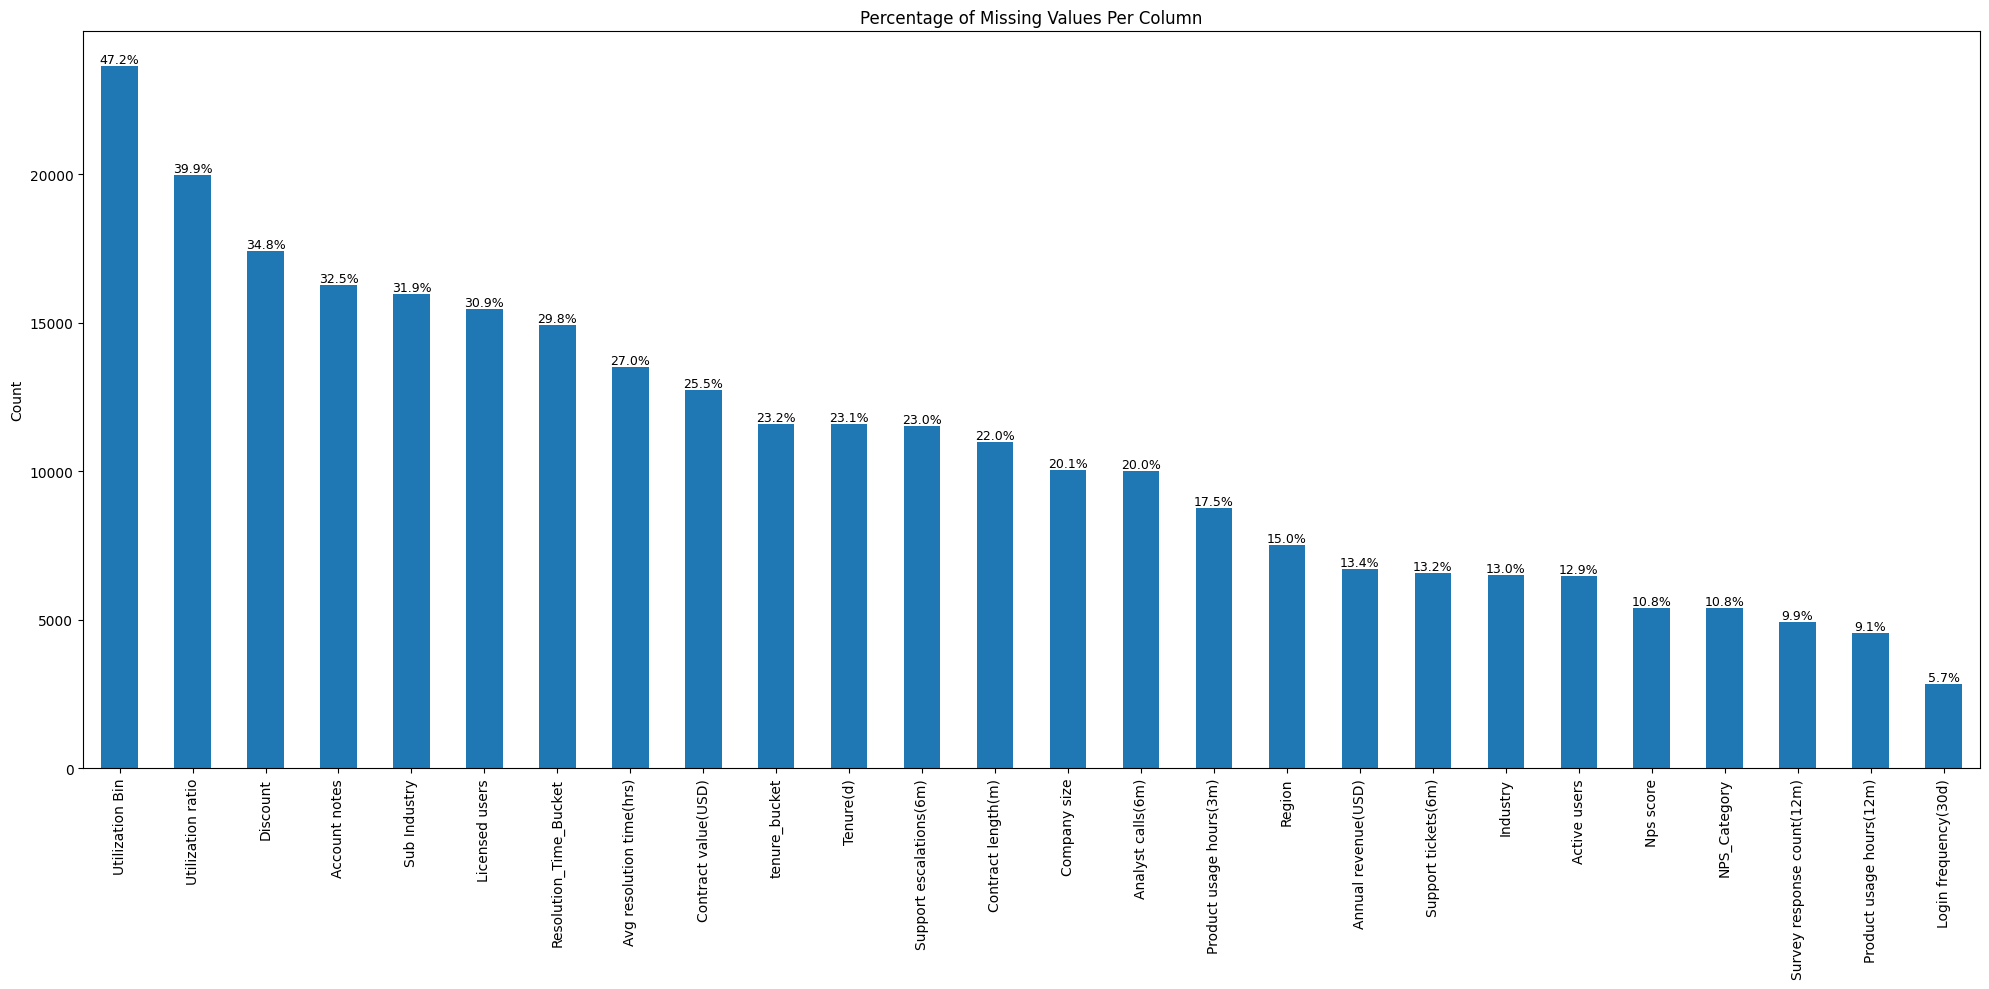

In [6]:
na_counts=df.isna().sum()
na_counts=na_counts[na_counts>0].sort_values(ascending=False)
na_props=na_counts/len(df)

ax=na_counts.plot.bar(figsize=(20,10),title="Percentage of Missing Values Per Column")
ax.set_ylabel("Count")
ax.grid(False)

for patch,prop in zip(ax.patches,na_props):
    ax.annotate(f"{prop:.1%}",
                (patch.get_x()+patch.get_width() / 2, patch.get_height()),
                ha="center",va="bottom",fontsize=9)
plt.tight_layout()
plt.show()

### **Missing values in discount**
Missing values in discount is not MCAR and carries a signal since it is due to system failure(some clients received discount but the system fails to record them). 34.8% of values are missing so removing them will lead to loss of information, imputing them with mean/median/mode would create bias because the distribution of discount is multimodal

#### Check if discount vary by industry, region, tenure

--- Discount Summary by Industry ---
                count      mean       std  min   25%  50%  75%  max
Industry                                                           
Energy         2793.0  0.113910  0.069412  0.0  0.05  0.1  0.2  0.2
Finance        5686.0  0.113938  0.069225  0.0  0.05  0.1  0.2  0.2
Healthcare     5596.0  0.114868  0.069356  0.0  0.05  0.1  0.2  0.2
Manufacturing  2851.0  0.113329  0.068846  0.0  0.05  0.1  0.2  0.2
Retail         2903.0  0.112177  0.068551  0.0  0.05  0.1  0.2  0.2
Saas           2958.0  0.115213  0.068452  0.0  0.05  0.1  0.2  0.2
Technology     5614.0  0.113582  0.068733  0.0  0.05  0.1  0.2  0.2

--- Discount Summary by Region ---
                count      mean       std  min   25%  50%  75%  max
Region                                                             
Apac           4083.0  0.116312  0.067763  0.0  0.05  0.1  0.2  0.2
Europe         7923.0  0.113858  0.069421  0.0  0.05  0.1  0.2  0.2
Latam          3845.0  0.113576  0.069273  

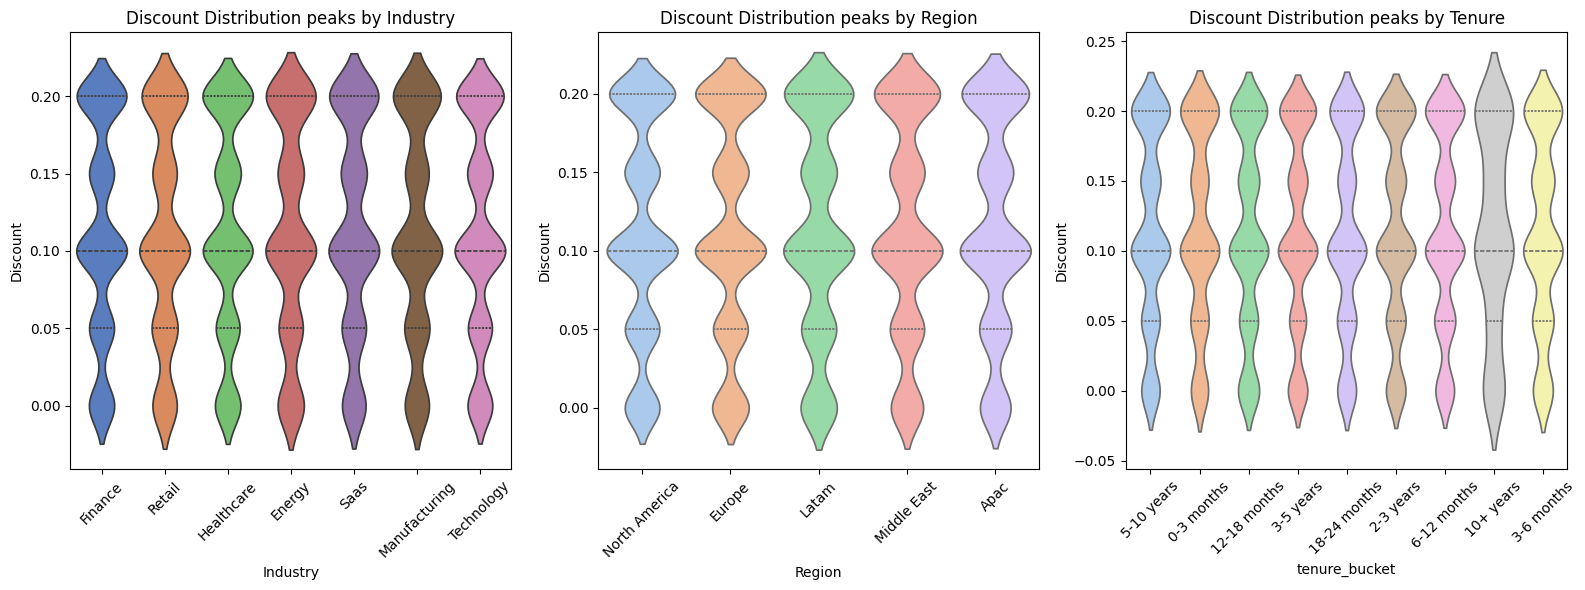

In [7]:
# --- 1. Statistical Summary (Numerical) ---
# This gives you the mean, median, and spread for each segment
print("--- Discount Summary by Industry ---")
print(df.groupby('Industry')['Discount'].describe())

print("\n--- Discount Summary by Region ---")
print(df.groupby('Region')['Discount'].describe())

print("\n--- Discount Summary by Tenure ---")
print(df.groupby('tenure_bucket')['Discount'].describe())

# --- 2. Visual Analysis (The 'Why') ---

# Set up a side-by-side plot
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

# Industry Analysis
# Violin plots are perfect here because they show the 'peaks' in your distribution
sns.violinplot(ax=axes[0], x='Industry', y='Discount', data=df, inner="quartile", palette="muted")
axes[0].set_title('Discount Distribution peaks by Industry')
axes[0].tick_params(axis='x', rotation=45)

# Region Analysis
sns.violinplot(ax=axes[1], x='Region', y='Discount', data=df, inner="quartile", palette="pastel")
axes[1].set_title('Discount Distribution peaks by Region')
axes[1].tick_params(axis='x', rotation=45)

sns.violinplot(ax=axes[2], x='tenure_bucket', y='Discount', data=df, inner="quartile", palette="pastel")
axes[2].set_title('Discount Distribution peaks by Tenure')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

#### Check for Group based random sampling imputation
Every single segment(Industry, Region, Tenure) has the same three primary peaks at 0.05 (5%), 0.10 (10%), and 0.20 (20%). This suggests the company has a global, standardized discount policy that doesn't change based on where the customer is or what industry/region they are in. Hence imputing missing values using grouped random sampling is discarded

In [8]:
def apply_bins(df):
    df_temp=df.copy()
    bins = [-0.01, 0.07, 0.15, 0.25]
    labels = ['Low', 'Medium', 'High']
    df_temp['Discount_Tier']=pd.cut(df_temp['Discount'],bins=bins,labels=labels)
    df_temp['Discount_Tier']=df_temp['Discount_Tier'].astype(str).replace('nan','Unknown')
    return df_temp
X_train=apply_bins(X_train)
X_test=apply_bins(X_test)

#### Tradeoffs between Random Sampling imputation(continuous) and Treating Missing values as separate category(categorical)


- Create a feature discount tier from discount using discretization

- Logistic regression assumes linearity hence it assumes the jump from 0% to 10% discount has exactly the same impact as the jump from 10% to 20%. If 10% or 20% discount relates to churn then the model will "average out" these effects and might give you a weaker prediction than the categorical approach that captures non linearity

- By creating a "Unknown" category, we capture the behavior behind the missing data

- Interpretability: It’s much easier to tell a stakeholder: "Customers with a 20% discount are 40% less likely to churn" than saying "For every 1% increase in discount, churn log-odds decrease by 0.045."

Challenges:
- Multicollinearity
- Dummy Variable Trap(overfitting risk)


#### **Missing values in Industry, Sub-Industry, Region**

In [9]:
X_train['Sub Industry']=X_train['Sub Industry'].fillna('Unknown')
X_test['Sub Industry']=X_test['Sub Industry'].fillna('Unknown')

X_train['Industry']=X_train['Industry'].fillna('Unknown')
X_test['Industry']=X_test['Industry'].fillna('Unknown')

X_train['Region']=X_train['Region'].fillna('Unknown')
X_test['Region']=X_test['Region'].fillna('Unknown')

#### **Missing values in Licensed users**

In [10]:
licensed_users_median=X_train['Licensed users'].median()
X_train['Licensed users']=X_train['Licensed users'].fillna(licensed_users_median)
X_test['Licensed users']=X_test['Licensed users'].fillna(licensed_users_median)

#### **Missing values in Avg resolution time**

In [11]:
pd.crosstab(
    X_train['Avg resolution time(hrs)'].isna(), 
    X_train['Support tickets(6m)'] == 0,
    rownames=['Is Resolution Time Missing?'],
    colnames=['Is Ticket Count Zero?']
)

Is Ticket Count Zero?,False,True
Is Resolution Time Missing?,,
False,28484,773
True,10474,269


In [12]:
res_median=X_train['Avg resolution time(hrs)'].median()
def handle_missing_values_avg_resolution_time(df,is_train=True):
    data=df.copy()
    data['unresolved_ticket_flag']=((data['Avg resolution time(hrs)'].isna()) &
                                    (data['Support tickets(6m)']>0))
    
    data['Avg resolution time(hrs)'] = np.where(
        (data['Avg resolution time(hrs)'].isna()) & (data['Support tickets(6m)'] == 0),
        0, 
        data['Avg resolution time(hrs)']
    )
    data['Avg resolution time(hrs)'] = data['Avg resolution time(hrs)'].fillna(res_median)

    return data

X_train=handle_missing_values_avg_resolution_time(X_train,is_train=True)
X_test=handle_missing_values_avg_resolution_time(X_test,is_train=False)

#### **Missing values in Revenue**

In [13]:
pd.DataFrame(df.groupby(df['Annual revenue(USD)'].isna())['Churn flag'].mean())

,Churn flag
Annual revenue(USD),
False,0.019795
True,0.018637


In [14]:
missing_revenue=df['Annual revenue(USD)'].isnull()
for col in ['Industry','Region']:
    print(missing_revenue.groupby(df[col]).mean().sort_values(ascending=False))

Industry
Manufacturing    0.144704
Saas             0.137692
Finance          0.136975
Healthcare       0.132211
Technology       0.131106
Retail           0.129261
Energy           0.126653
Name: Annual revenue(USD), dtype: float64
Region
Europe           0.138067
Apac             0.133759
Middle East      0.133575
North America    0.132640
Latam            0.131107
Name: Annual revenue(USD), dtype: float64


In [15]:
revenue_median=X_train['Annual revenue(USD)'].median()
X_train['Annual revenue(USD)']=X_train['Annual revenue(USD)'].fillna(revenue_median)
X_test['Annual revenue(USD)']=X_test['Annual revenue(USD)'].fillna(revenue_median)

### Ran a three-stage missingness diagnosis on revenue
I tested MNAR by comparing churn rates across missing and non-missing groups, rates were nearly identical at 1.98% vs 1.86%, ruling out MNAR. Then I tested MAR by checking if missingness varied across industry and region, the spread was less than 2 percentage points across all groups, confirming MCAR. 

#### **Missing values in analyst calls**

In [16]:
zero_calls = df[df['Analyst calls(6m)'] == 0]['Churn flag'].mean()
has_calls = df[df['Analyst calls(6m)'] > 0]['Churn flag'].mean()

print(f"Churn rate - zero calls: {zero_calls:.3f}")
print(f"Churn rate - has calls: {has_calls:.3f}")

Churn rate - zero calls: 0.035
Churn rate - has calls: 0.009


In [17]:
X_train['Analyst calls(6m)']=X_train['Analyst calls(6m)'].fillna(0)
X_test['Analyst calls(6m)']=X_test['Analyst calls(6m)'].fillna(0)

### 
I validated the zero-fill assumption in analyst calls by comparing churn rates — accounts with zero analyst calls churned at 3.5% versus 0.9% for accounts with calls, a 4x difference. This confirmed that missingness in analyst calls is a genuine churn signal, not noise. I zero-filled the feature and retained the missing indicator to preserve the distinction between recorded zero engagement and unrecorded engagement — since both map to the same imputed value but may carry different risk profiles."

#### **Missing values in Tenure**

In [18]:
tenure_median=X_train['Tenure(d)'].median()
X_train['Tenure(d)']=X_train['Tenure(d)'].fillna(tenure_median)
X_test['Tenure(d)']=X_test['Tenure(d)'].fillna(tenure_median)

#### **Missing values in Contract length, Product usage hours (3m,12m), NPS score,active users**

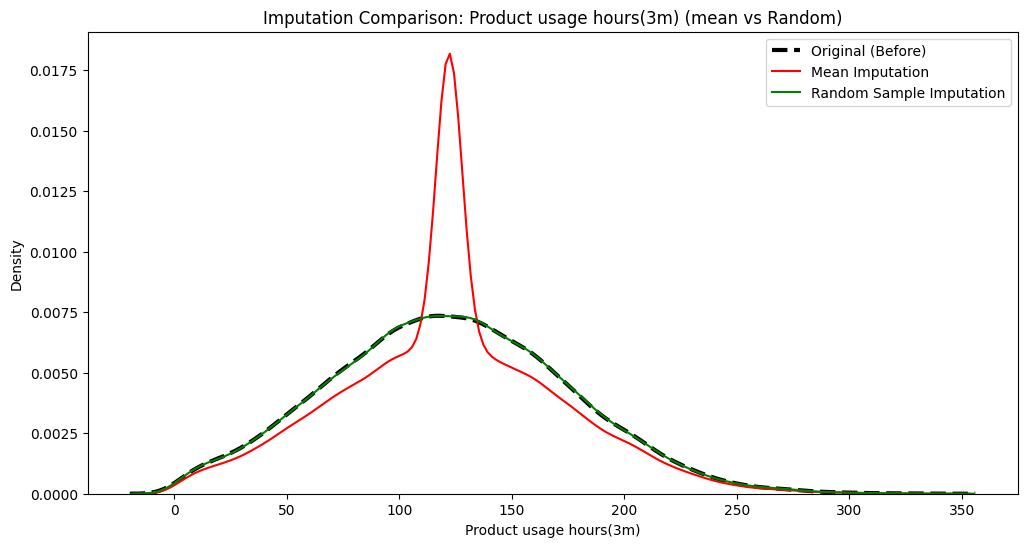

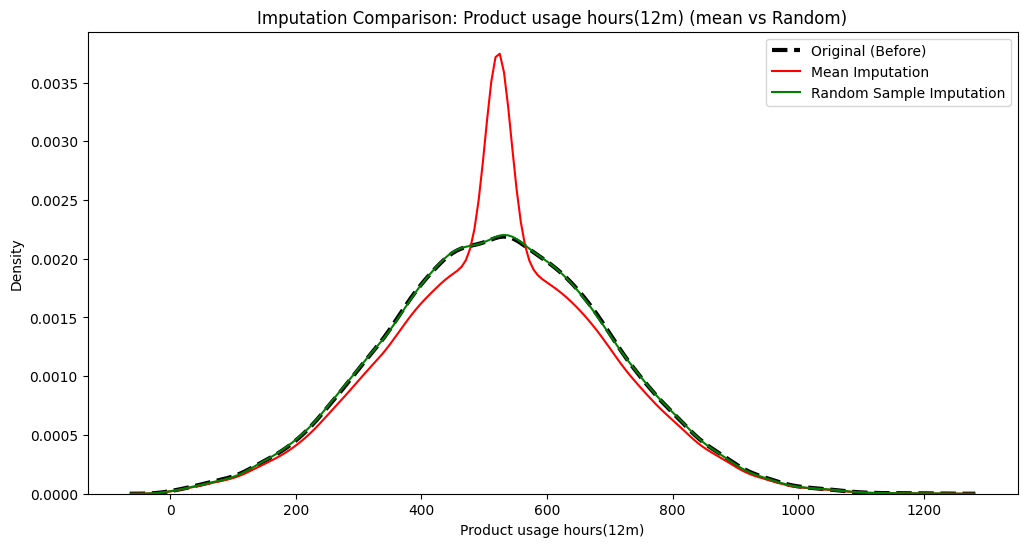

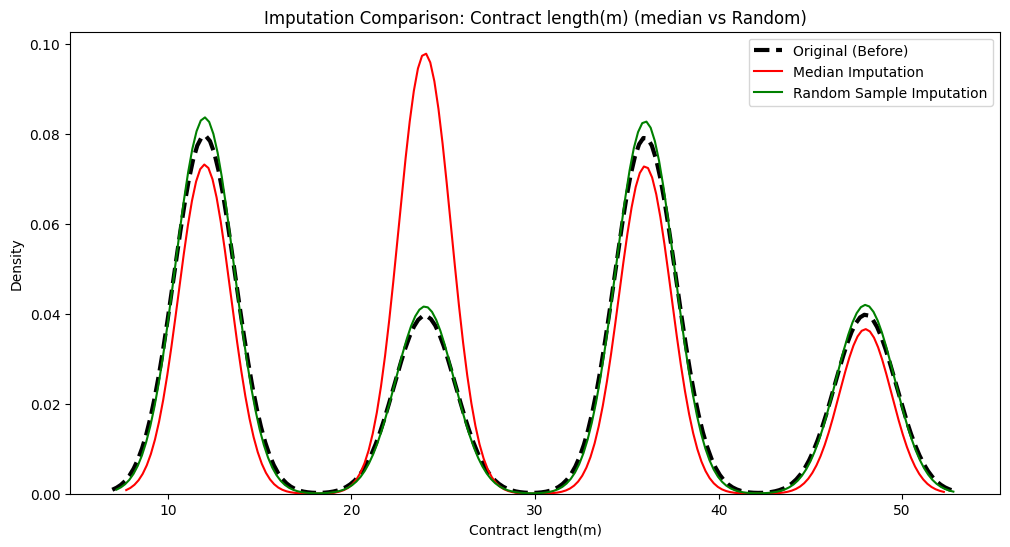

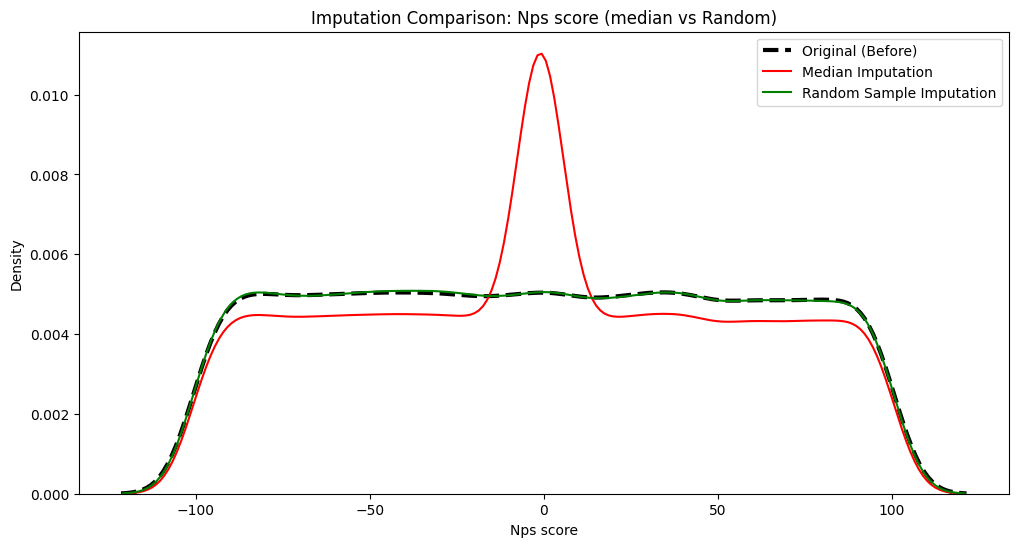

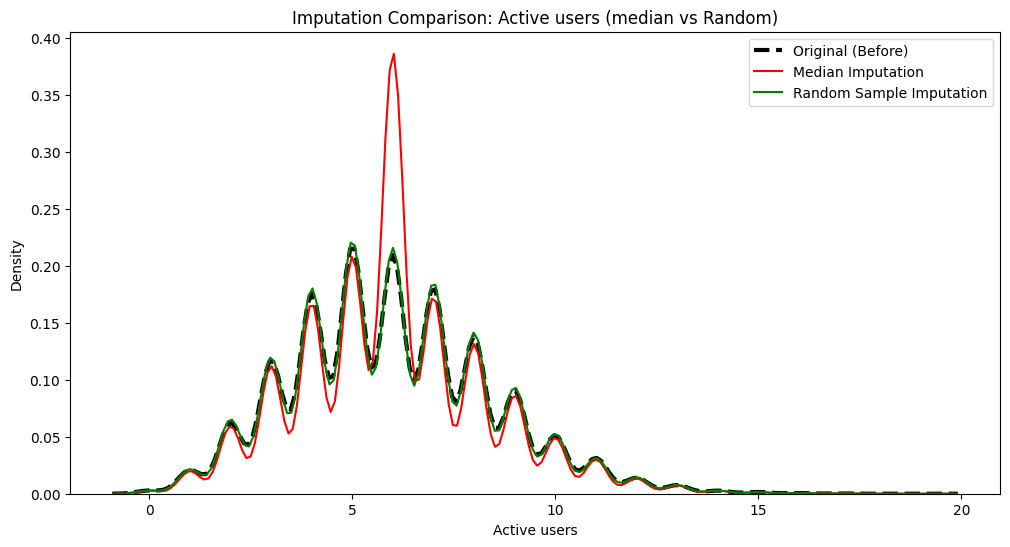

In [19]:
def plot_imputation_comparison(df, column, strategy='median'):
    plt.figure(figsize=(12, 6))
    
    # 1. Original Distribution (dropna to see the 'true' shape)
    sns.kdeplot(df[column].dropna(), label='Original (Before)', color='black', lw=3, ls='--')
    
    # 2. Mean or Median Imputation
    if strategy == 'mean':
        val = df[column].mean()
    else:
        val = df[column].median()
    
    df_simple = df[column].fillna(val)
    sns.kdeplot(df_simple, label=f'{strategy.capitalize()} Imputation', color='red')
    
    # 3. Random Sample Imputation
    # (Using the logic from your function)
    observed = df[column].dropna()
    null_indices = df[df[column].isnull()].index
    samples = observed.sample(len(null_indices), random_state=42, replace=True)
    samples.index = null_indices
    
    df_random = df[column].copy()
    df_random.loc[null_indices] = samples
    sns.kdeplot(df_random, label='Random Sample Imputation', color='green')
    
    plt.title(f'Imputation Comparison: {column} ({strategy} vs Random)')
    plt.xlabel(column)
    plt.legend()
    plt.show()

# Execution for your specific variables
mean_cols = ['Product usage hours(3m)', 'Product usage hours(12m)']
median_cols = ['Contract length(m)', 'Nps score', 'Active users']

for col in mean_cols:
    plot_imputation_comparison(X_train, col, strategy='mean')

for col in median_cols:
    plot_imputation_comparison(X_train, col, strategy='median')

In [20]:
def apply_random_sample_imputation(train_df, test_df, column_name):
    # 1. Get the observed (non-null) values from the Training Set only
    observed_values = train_df[column_name].dropna()
    
    # 2. Impute X_train
    null_indices_train = train_df[train_df[column_name].isnull()].index
    if not null_indices_train.empty:
        samples_train = observed_values.sample(len(null_indices_train), random_state=42, replace=True)
        samples_train.index = null_indices_train
        train_df.loc[null_indices_train, column_name] = samples_train

    # 3. Impute X_test using the distribution from X_train
    null_indices_test = test_df[test_df[column_name].isnull()].index
    if not null_indices_test.empty:
        # We sample from observed_values (which came from train_df)
        samples_test = observed_values.sample(len(null_indices_test), random_state=42, replace=True)
        samples_test.index = null_indices_test
        test_df.loc[null_indices_test, column_name] = samples_test
        
    return train_df, test_df

# Usage:
X_train, X_test = apply_random_sample_imputation(X_train, X_test, 'Contract length(m)')
X_train, X_test = apply_random_sample_imputation(X_train, X_test, 'Product usage hours(3m)')
X_train, X_test = apply_random_sample_imputation(X_train, X_test, 'Product usage hours(12m)')
X_train, X_test = apply_random_sample_imputation(X_train, X_test, 'Nps score')
X_train, X_test = apply_random_sample_imputation(X_train, X_test, 'Active users')

##
* By "squeezing" the distribution toward the center, mean/median imputation artificially shrink the standard deviation. This makes data look more consistent than it actually is. Furthermore, it dilutes the relationship (correlation) between that variable and your target (Churn). If the missing values actually had a pattern, you’ve just buried it under an average

* If people who churn usually have very low usage, but you fill their missing data with the "average" (which is higher), you are accidentally teaching the model that "average usage users churn". The model won't be able to learn the churn risk. 

* Example: If a "loyal" client and a "churning" client both have missing data, and you fill both with the average (50 hours), they now look identical to the model.

   * The "Hidden" Churners: The clients who were actually at 5 usage hours (high risk) now look like they have 50 hours (medium risk). The model misses the "red flag."

   * The "Diluted" Loyals: The clients who were actually at 95 usage hours (low risk) now look like they have 50 hours. The model might start to think their loyalty is "uncertain."

#### **Missing values in contract value**

In [21]:
X_train.drop(columns=['NPS_Category'],axis=1,inplace=True)
X_test.drop(columns=['NPS_Category'],axis=1,inplace=True)

In [22]:
X_train['NPS_Category'] = pd.cut(X_train['Nps score'], 
                           bins=[-101, 0, 50, 100], 
                           labels=['Detractor (-100 to 0)', 'Passive (1 to 50)', 'Promoter (51 to 100)'])
X_test['NPS_Category'] = pd.cut(X_test['Nps score'], 
                           bins=[-101, 0, 50, 100], 
                           labels=['Detractor (-100 to 0)', 'Passive (1 to 50)', 'Promoter (51 to 100)'])


In [23]:
nps_bucket_mean=X_train.groupby('NPS_Category')['Contract value(USD)'].mean()

X_train['Contract value(USD)']=X_train.apply(
    lambda row: nps_bucket_mean[row['NPS_Category']] if pd.isna(row['Contract value(USD)'])
    else row['Contract value(USD)'],axis=1
)

X_test['Contract value(USD)']=X_test.apply(
    lambda row: nps_bucket_mean[row['NPS_Category']] if pd.isna(row['Contract value(USD)'])
    else row['Contract value(USD)'],axis=1
)

###
* Here we drop the nps category column that was there in data before and created it again since we handled missing values in nps score

#### **Missing values in support escalations**

In [24]:
industry_region_median=X_train.groupby(['Industry','Region'])['Support escalations(6m)'].median()

X_train['Support escalations(6m)'] = X_train['Support escalations(6m)'].fillna(
    pd.Series(X_train.set_index(['Industry', 'Region']).index.map(industry_region_median),index=X_train.index)
)

X_test['Support escalations(6m)'] = X_test['Support escalations(6m)'].fillna(
    pd.Series(X_test.set_index(['Industry', 'Region']).index.map(industry_region_median),index=X_test.index)
)

#### **Missing values in company size**

In [25]:
def apply_bins(df):
    df_temp_2=df.copy()
    bins = [0,500,2000,6000,np.inf]
    labels = ['Startup', 'Mid-Size', 'Large','Enterprise']
    df_temp_2['Company size']=pd.cut(df_temp_2['Company size'],bins=bins,labels=labels)
    return df_temp_2
X_train=apply_bins(X_train)
X_test=apply_bins(X_test)

###
* In my exploratory data analysis, I noticed a massive density peak under 2,000. By splitting this into Startup (0–500) and Mid-Market (500–2k), I’m addressing the 'Small Business' volatility. Startups have a much higher churn risk due to limited funding or pivots. If I grouped them with 1,500-employee firms, that high-risk signal would get diluted, and the model would struggle to identify which small accounts actually need intervention.

* Buckets:
  - 0–500	Startup ->	High-risk; sensitive to immediate ROI and price.
  - 500–2000 ->	Mid-Market	The "Sweet Spot"; high adoption, moderate stability.
  - 2000–6000 -> Large	Transitioning; influenced by departmental shifts.
  - 6000+ -> Enterprise	Strategic partners; very low churn, high revenue impact.

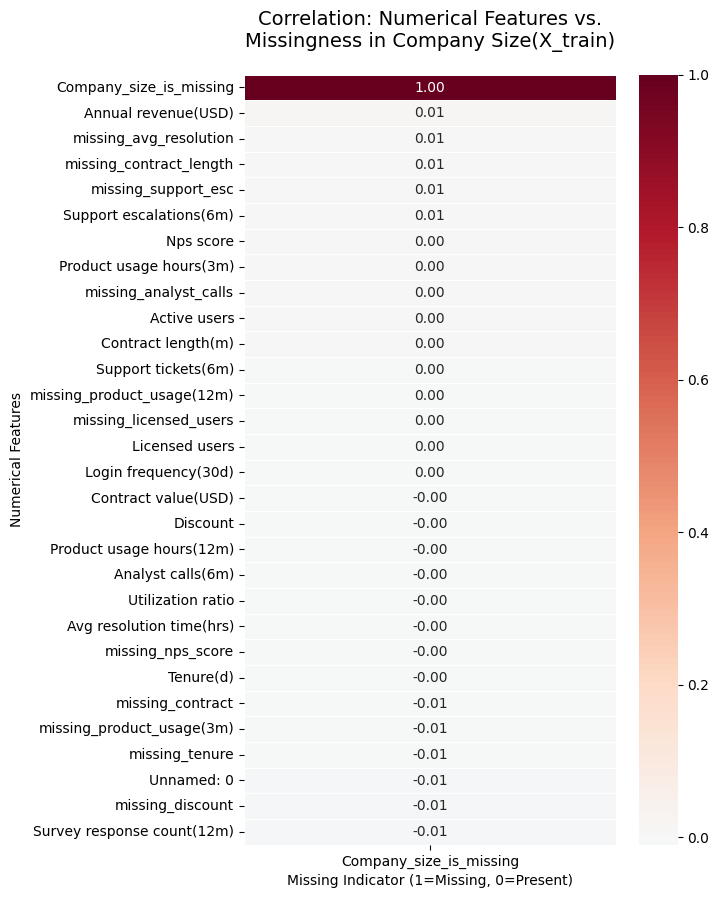

In [26]:
from scipy.stats import chi2_contingency

# Create a binary flag: 1 if missing, 0 if present
X_train['Company_size_is_missing'] = X_train['Company size'].isnull().astype(int)
numerical_cols=X_train.select_dtypes(include=[np.number]).columns

corr_matrix = X_train[numerical_cols].corr()[['Company_size_is_missing']].sort_values(by='Company_size_is_missing', ascending=False)

# 2. Plot the heatmap
plt.figure(figsize=(6, 10))
sns.heatmap(corr_matrix, 
            annot=True, 
            cmap='RdBu_r', # Red for positive, Blue for negative correlation
            center=0, 
            fmt=".2f", 
            linewidths=0.5)

plt.title("Correlation: Numerical Features vs.\nMissingness in Company Size(X_train)", fontsize=14, pad=20)
plt.xlabel("Missing Indicator (1=Missing, 0=Present)")
plt.ylabel("Numerical Features")
plt.show()

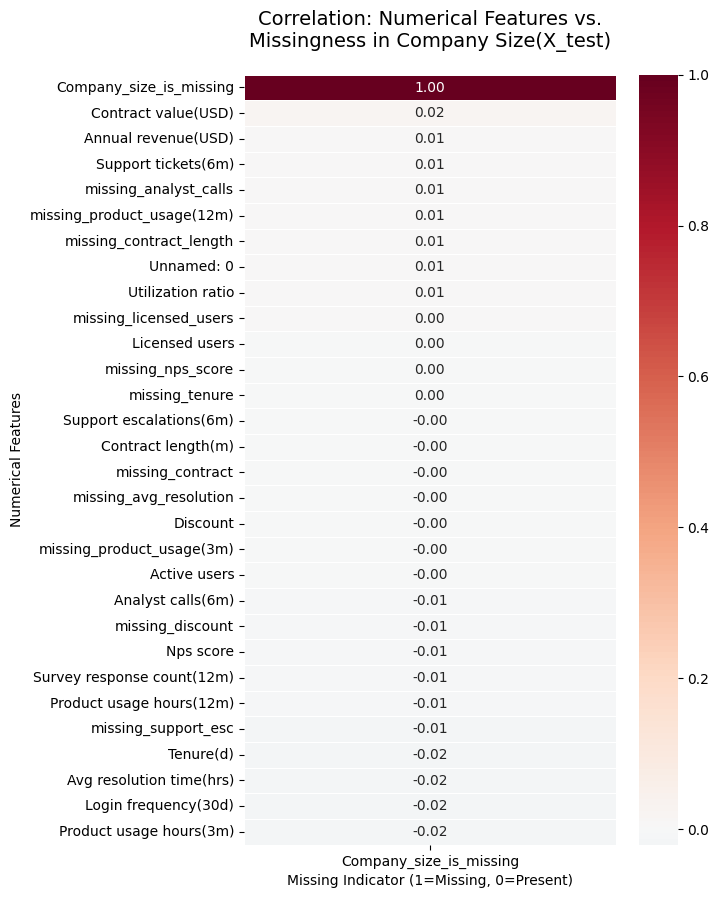

In [27]:
# Create a binary flag: 1 if missing, 0 if present
X_test['Company_size_is_missing'] = X_test['Company size'].isnull().astype(int)
numerical_cols=X_train.select_dtypes(include=[np.number]).columns

corr_matrix = X_test[numerical_cols].corr()[['Company_size_is_missing']].sort_values(by='Company_size_is_missing', ascending=False)

# 2. Plot the heatmap
plt.figure(figsize=(6, 10))
sns.heatmap(corr_matrix, 
            annot=True, 
            cmap='RdBu_r', # Red for positive, Blue for negative correlation
            center=0, 
            fmt=".2f", 
            linewidths=0.5)

plt.title("Correlation: Numerical Features vs.\nMissingness in Company Size(X_test)", fontsize=14, pad=20)
plt.xlabel("Missing Indicator (1=Missing, 0=Present)")
plt.ylabel("Numerical Features")
plt.show()

In [28]:
def test_mar_chi2(df, indicator_col, categorical_col):
    # Create a cross-tabulation (contingency table)
    contingency_table = pd.crosstab(df[indicator_col], df[categorical_col])
    
    # Run the Chi-Square test
    chi2, p, dof, expected = chi2_contingency(contingency_table)
    
    print(f"\n--- Chi-Square Test: {categorical_col} vs Missingness ---")
    print(f"Chi2 Statistic: {chi2:.4f}")
    print(f"P-Value: {p:.4f}")
    
    if p < 0.05:
        print(f"Result: Significant relationship found! Missingness is likely MAR (linked to {categorical_col}).")
    else:
        print(f"Result: No significant relationship. Missingness does not appear to depend on {categorical_col}.")

# Example usage (Replace 'Industry' with your actual column name)
test_mar_chi2(X_train, 'Company_size_is_missing', 'Industry')


--- Chi-Square Test: Industry vs Missingness ---
Chi2 Statistic: 7.5917
P-Value: 0.3700
Result: No significant relationship. Missingness does not appear to depend on Industry.


In [29]:
def test_mar_chi2(df, indicator_col, categorical_col):
    # Create a cross-tabulation (contingency table)
    contingency_table = pd.crosstab(df[indicator_col], df[categorical_col])
    
    # Run the Chi-Square test
    chi2, p, dof, expected = chi2_contingency(contingency_table)
    
    print(f"\n--- Chi-Square Test: {categorical_col} vs Missingness ---")
    print(f"Chi2 Statistic: {chi2:.4f}")
    print(f"P-Value: {p:.4f}")
    
    if p < 0.05:
        print(f"Result: Significant relationship found! Missingness is likely MAR (linked to {categorical_col}).")
    else:
        print(f"Result: No significant relationship. Missingness does not appear to depend on {categorical_col}.")

# Example usage (Replace 'Industry' with your actual column name)
test_mar_chi2(X_train, 'Company_size_is_missing', 'Region')


--- Chi-Square Test: Region vs Missingness ---
Chi2 Statistic: 4.4846
P-Value: 0.4820
Result: No significant relationship. Missingness does not appear to depend on Region.


###
* Missingness in company size is not related to any of the observed variables in the data hence this not the case of MAR. Here missigness might tied to company size itself(Small companies might hesitate to report their size in fear of being perceived as unstable or inexperienced). This is a case of MNAR

* Treat missing values as a separate category

In [30]:
X_train['Company size']=X_train['Company size'].cat.add_categories('Unknown')
X_test['Company size']=X_test['Company size'].cat.add_categories('Unknown')
X_train['Company size']=X_train['Company size'].fillna('Unknown')
X_test['Company size']=X_test['Company size'].fillna('Unknown')

#### **Missing values in support tickets**

In [31]:
tickets_median = X_train['Support tickets(6m)'].median()

X_train['Support tickets(6m)'] = X_train['Support tickets(6m)'].fillna(tickets_median)
X_test['Support tickets(6m)'] = X_test['Support tickets(6m)'].fillna(tickets_median)

#### **Missing values in login frequency**

In [32]:
login_frequency_median = X_train['Login frequency(30d)'].median()

X_train['Login frequency(30d)'] = X_train['Login frequency(30d)'].fillna(login_frequency_median )
X_test['Login frequency(30d)'] = X_test['Login frequency(30d)'].fillna(login_frequency_median)

## Encoding Categorical Variables

In [33]:
def no_of_categories(df,col):
        unique_categories=len(df[col].unique())
        return unique_categories

In [34]:
unique_cat_industry=no_of_categories(X_train,'Industry')
unique_cat_sub_industry=no_of_categories(X_train,'Sub Industry')
unique_cat_region=no_of_categories(X_train,'Region')
unique_cat_company_size=no_of_categories(X_train,'Company size')
unique_cat_discount=no_of_categories(X_train,'Discount_Tier')

print(f'No of unique categories in Industry: {unique_cat_industry}')
print('----------------------------------------------------------')
print(f'No of unique categories in Sub Industry: {unique_cat_sub_industry}')
print('----------------------------------------------------------')
print(f'No of unique categories in Region: {unique_cat_region}')
print('----------------------------------------------------------')
print(f'No of unique categories in Company Size: {unique_cat_company_size}')
print('----------------------------------------------------------')
print(f'No of unique categories in Discount: {unique_cat_discount}')

No of unique categories in Industry: 8
----------------------------------------------------------
No of unique categories in Sub Industry: 8
----------------------------------------------------------
No of unique categories in Region: 6
----------------------------------------------------------
No of unique categories in Company Size: 5
----------------------------------------------------------
No of unique categories in Discount: 4


In [35]:
discount_order=['Unknown','Low','Medium','High']
company_size_order=['Unknown','Startup','Mid-Size','Large','Enterprise']

ordinal_encoder=OrdinalEncoder(
    categories=[discount_order,company_size_order],
    handle_unknown='use_encoded_value',
    unknown_value=np.nan
)

cols=['Discount_Tier','Company size']
X_train[cols]=ordinal_encoder.fit_transform(X_train[cols])
X_test[cols]=ordinal_encoder.transform(X_test[cols])

In [36]:
cols=['Unnamed: 0','Sub Industry','Survey response count(12m)','Account notes',
      'Utilization ratio','Utilization Bin','Resolution_Time_Bucket','tenure_bucket','NPS_Category','Discount']
X_train.drop(columns=cols,axis=1,inplace=True)
X_test.drop(columns=cols,axis=1,inplace=True)

In [37]:
ohe_cols=['Industry','Region']
ohe=OneHotEncoder(
    drop='first', # Avoids the "Dummy Variable Trap"
    sparse_output=False, # stores every 1 and 0 in a standard grid
    handle_unknown='ignore'

)

ohe_train=ohe.fit_transform(X_train[ohe_cols])
ohe_test=ohe.transform(X_test[ohe_cols])

ohe_feature_names=ohe.get_feature_names_out(ohe_cols)
ohe_train_df=pd.DataFrame(ohe_train,columns=ohe_feature_names,index=X_train.index)
ohe_test_df=pd.DataFrame(ohe_test,columns=ohe_feature_names,index=X_test.index)

X_train=pd.concat(
    [X_train.drop(columns=ohe_cols),ohe_train_df],axis=1
)

X_test=pd.concat(
    [X_test.drop(columns=ohe_cols),ohe_test_df],axis=1
)

## Handling Outliers

#### **Outliers in product usage(3m) and product usage(12m)**

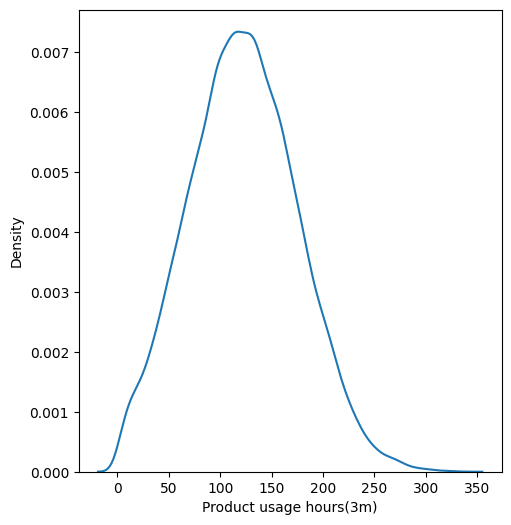

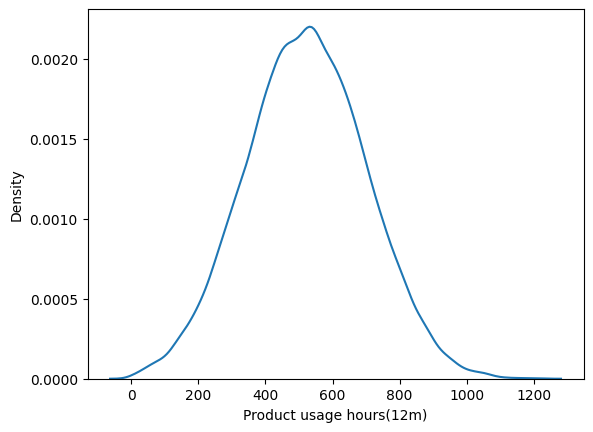

In [38]:
cols=['Product usage hours(3m)','Product usage hours(12m)']
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
for column in cols:
    sns.kdeplot(data=X_train,x=column)
    plt.show()

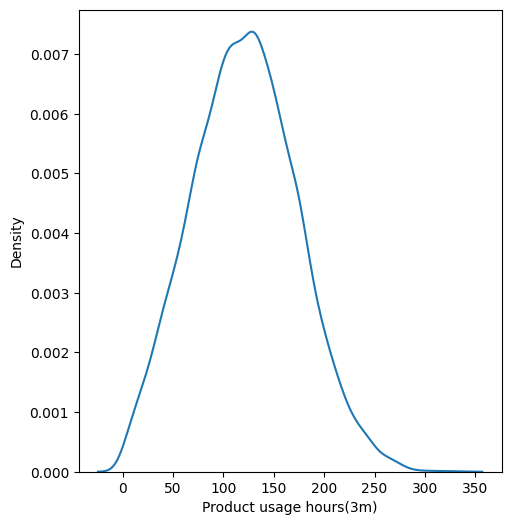

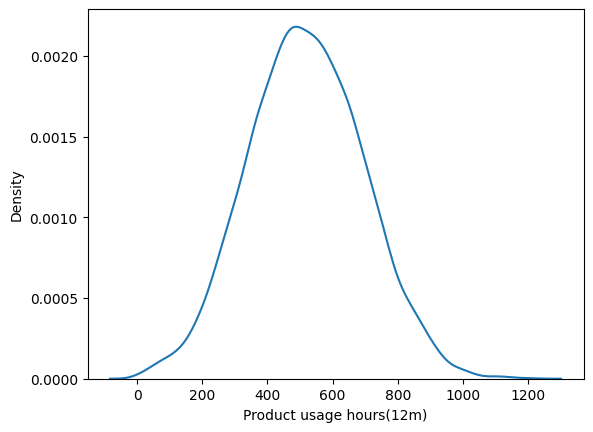

In [39]:
cols=['Product usage hours(3m)','Product usage hours(12m)']
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
for column in cols:
    sns.kdeplot(data=X_test,x=column)
    plt.show()

###
* Near-zero values (~0–20 hrs) are your highest churn risk — customers barely using the product have little reason to stay. These are not noise, they're a signal

* Right tail looks like genuine heavy users who are using the product heavily, not data entry errors

* Will not remove outliers since here outliers might not be noise


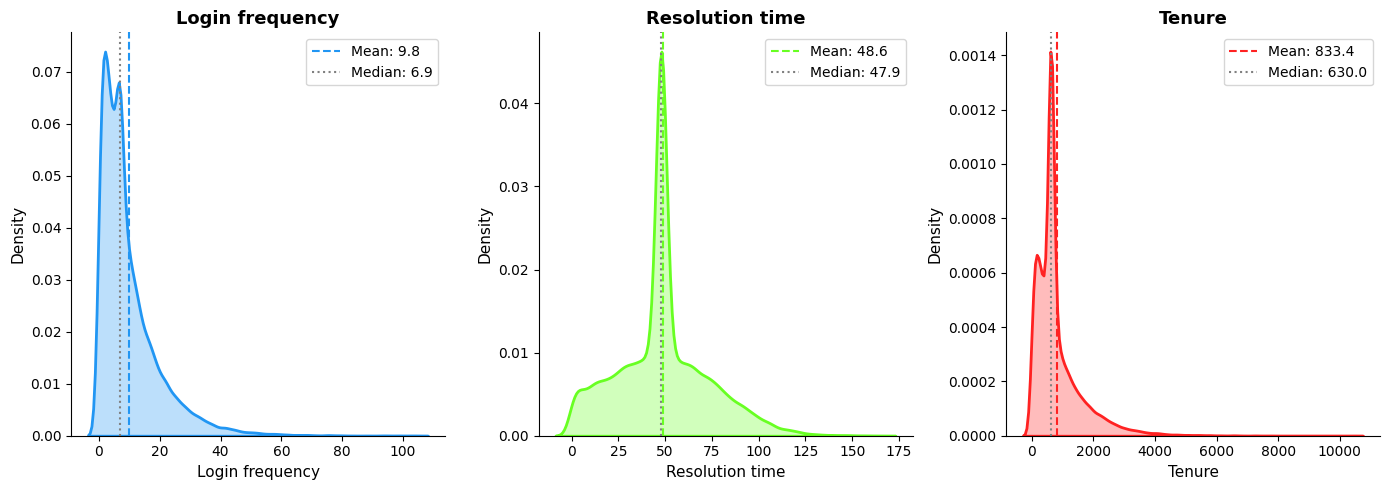

In [40]:
cols=['Login frequency(30d)','Avg resolution time(hrs)','Tenure(d)']
fig,axes=plt.subplots(1,3,figsize=(14,5))

colors = ['#2196F3', "#68FF22", "#FF2222"]
titles = ['Login frequency', 'Resolution time','Tenure']

for i,(col,color,title) in enumerate(zip(cols,colors,titles)):
    sns.kdeplot(data=X_train,x=col, ax=axes[i], color=color, fill=True, alpha=0.3, linewidth=2)
    axes[i].set_title(title, fontsize=13, fontweight='bold')
    axes[i].set_xlabel(title, fontsize=11)
    axes[i].set_ylabel('Density', fontsize=11)
    axes[i].axvline(X_train[col].mean(), color=color, linestyle='--', linewidth=1.5, label=f'Mean: {X_train[col].mean():.1f}')
    axes[i].axvline(X_train[col].median(), color='gray', linestyle=':', linewidth=1.5, label=f'Median: {X_train[col].median():.1f}')
    axes[i].legend(fontsize=10)
    axes[i].grid(False)
    sns.despine(ax=axes[i])
plt.tight_layout()
plt.show()

In [41]:
X_train['login_freq_log'] = np.log1p(X_train['Login frequency(30d)'])
X_test['login_freq_log'] = np.log1p(X_test['Login frequency(30d)'])

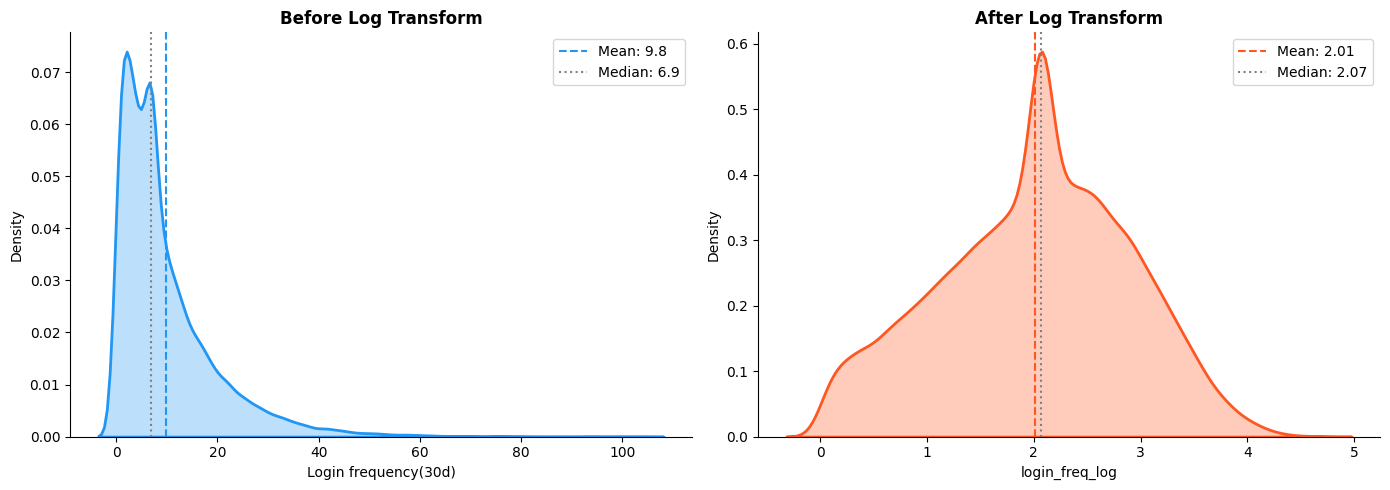

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.kdeplot(data=X_train, x='Login frequency(30d)', ax=axes[0], color='#2196F3', fill=True, alpha=0.3, linewidth=2)
axes[0].set_title('Before Log Transform', fontweight='bold')
axes[0].axvline(X_train['Login frequency(30d)'].mean(), color='#2196F3', linestyle='--', label=f"Mean: {X_train['Login frequency(30d)'].mean():.1f}")
axes[0].axvline(X_train['Login frequency(30d)'].median(), color='gray', linestyle=':', label=f"Median: {X_train['Login frequency(30d)'].median():.1f}")
axes[0].legend()

sns.kdeplot(data=X_train, x='login_freq_log', ax=axes[1], color='#FF5722', fill=True, alpha=0.3, linewidth=2)
axes[1].set_title('After Log Transform', fontweight='bold')
axes[1].axvline(X_train['login_freq_log'].mean(), color='#FF5722', linestyle='--', label=f"Mean: {X_train['login_freq_log'].mean():.2f}")
axes[1].axvline(X_train['login_freq_log'].median(), color='gray', linestyle=':', label=f"Median: {X_train['login_freq_log'].median():.2f}")
axes[1].legend()

sns.despine()
plt.tight_layout()
plt.show()

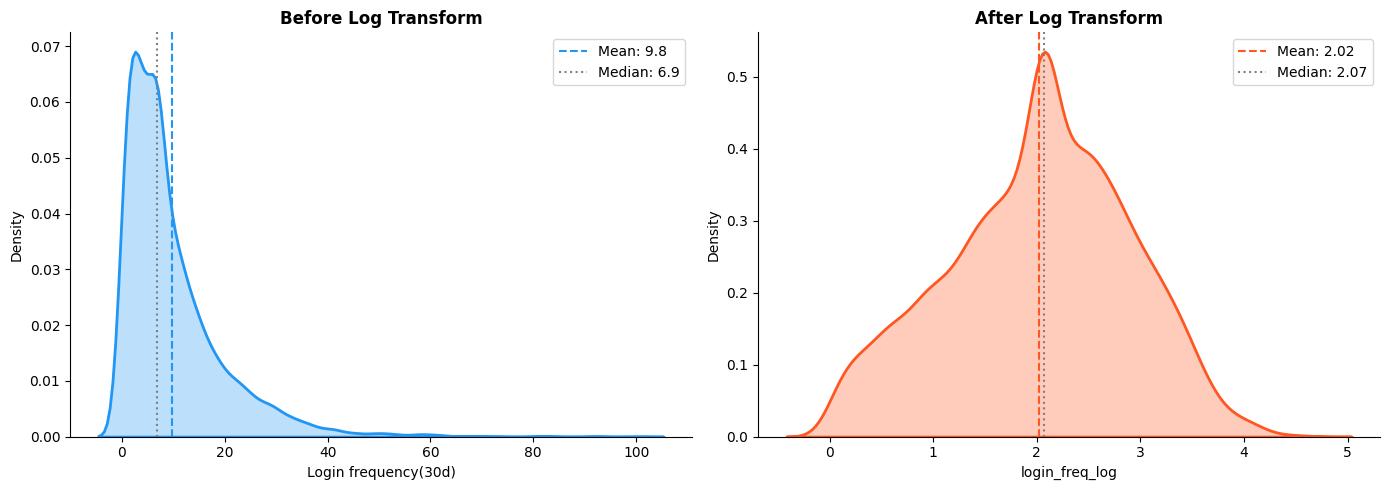

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.kdeplot(data=X_test, x='Login frequency(30d)', ax=axes[0], color='#2196F3', fill=True, alpha=0.3, linewidth=2)
axes[0].set_title('Before Log Transform', fontweight='bold')
axes[0].axvline(X_test['Login frequency(30d)'].mean(), color='#2196F3', linestyle='--', label=f"Mean: {X_test['Login frequency(30d)'].mean():.1f}")
axes[0].axvline(X_test['Login frequency(30d)'].median(), color='gray', linestyle=':', label=f"Median: {X_test['Login frequency(30d)'].median():.1f}")
axes[0].legend()

sns.kdeplot(data=X_test, x='login_freq_log', ax=axes[1], color='#FF5722', fill=True, alpha=0.3, linewidth=2)
axes[1].set_title('After Log Transform', fontweight='bold')
axes[1].axvline(X_test['login_freq_log'].mean(), color='#FF5722', linestyle='--', label=f"Mean: {X_test['login_freq_log'].mean():.2f}")
axes[1].axvline(X_test['login_freq_log'].median(), color='gray', linestyle=':', label=f"Median: {X_test['login_freq_log'].median():.2f}")
axes[1].legend()

sns.despine()
plt.tight_layout()
plt.show()


* Login Frequency outliers:
      
      - Near-zero logins → high churn risk signal

      - Very high logins → could be super-engaged users
      
      - Real behaviour

* Resolution time outliers: 
    -    High resolution time → poor support experience → churn risk
    -    These are not errors, they're meaningful signals

* Tenure outliers:
     - Very long tenure customers are likely sticky, established accounts — lowest churn risk
     - Very short tenure customers are in the danger zone — early churn window

### Feature Construction

In [44]:
X_train['Utilization Rate']=X_train['Active users']/X_train['Licensed users']
X_test['Utilization Rate']=X_test['Active users']/X_test['Licensed users']

In [45]:
X_train['Escalation Rate']=(X_train['Support escalations(6m)']/ (X_train['Support tickets(6m)'] + 1)).round(2)
X_test['Escalation Rate']=(X_test['Support escalations(6m)']/ (X_test['Support tickets(6m)'] + 1)).round(2)

In [46]:
X_train['Usage Trend']=(X_train['Product usage hours(3m)']/(X_train['Product usage hours(12m)'] /4 + 1)).round(2)
X_test['Usage Trend']=(X_test['Product usage hours(3m)']/(X_test['Product usage hours(12m)'] /4 + 1)).round(2)

In [47]:
X_train['Tenure(year)']=X_train['Tenure(d)']/365
X_test['Tenure(year)']=X_test['Tenure(d)']/365

In [48]:
X_train['Tenure(year)']=X_train['Tenure(year)'].round(2)
X_test['Tenure(year)']=X_test['Tenure(year)'].round(2)

In [49]:
X_train['Usage per User(3m)'] = X_train['Product usage hours(3m)'] / (X_train['Active users'] + 1)
X_test['Usage per User(3m)'] = X_test['Product usage hours(3m)'] / (X_test['Active users'] + 1)

In [50]:
X_train['Analyst_calls_rate']=(X_train['Analyst calls(6m)']/(X_train['Active users']+1)).round(2)
X_test['Analyst_calls_rate']=(X_test['Analyst calls(6m)']/(X_test['Active users']+1)).round(2)

In [51]:
columns=['Tenure(d)','missing_discount','missing_licensed_users','missing_avg_resolution',
         'missing_contract','missing_tenure','missing_support_esc','missing_product_usage(3m)',
         'missing_product_usage(12m)','missing_nps_score','missing_contract_length','Login frequency(30d)']

X_train.drop(columns=columns,axis=1,inplace=True)
X_test.drop(columns=columns,axis=1,inplace=True)


## Feature Scaling

In [52]:
cols_to_scale = [
    'Annual revenue(USD)',
    'Contract value(USD)',
    'Contract length(m)',
    'Product usage hours(3m)',
    'Product usage hours(12m)',
    'Active users',
    'Licensed users',
    'Analyst calls(6m)',
    'Support tickets(6m)',
    'Support escalations(6m)',
    'Avg resolution time(hrs)',
    'Nps score',
    'login_freq_log',
    'Utilization Rate',
    'Escalation Rate',
    'Tenure(year)',
    'Usage per User(3m)',
    'Analyst_calls_rate',
    'Usage Trend'
]

len(cols_to_scale)

19

In [53]:
scaler=RobustScaler()
X_train[cols_to_scale]=scaler.fit_transform(X_train[cols_to_scale])
X_test[cols_to_scale]=scaler.transform(X_test[cols_to_scale])

## Handling Class Imbalance and Model Development

In [54]:
SCALE=round(98.04/1.96) # (neg/pos ratio)
RANDOM_STATE=42
N_ITER=10  # RandomizedSearch iterations per model
CV=5
SCORING='average_precision' # PR-AUC — best metric for severe imbalance
sample_weights_train=compute_sample_weight(class_weight='balanced',y=y_train)

In [55]:
def evaluate_clf(y_true, y_pred, y_prob):
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    roc_auc = roc_auc_score(y_true, y_prob)  # ✅ use probabilities
    pr_auc = average_precision_score(y_true, y_prob)  # ✅ correct PR-AUC
    
    return acc, f1, precision, recall, roc_auc, pr_auc

In [56]:
models = {
    "Random Forest": RandomForestClassifier(class_weight='balanced'),
    "Decision Tree": DecisionTreeClassifier(class_weight='balanced'),
    "Gradient Boosting": GradientBoostingClassifier(),
    "Logistic Regression": LogisticRegression(class_weight='balanced'),
    "K-Neighbors Classifier": KNeighborsClassifier(n_neighbors=5,weights='distance'),
    "XGBClassifier": XGBClassifier(scale_pos_weight=SCALE), 
    "CatBoosting Classifier": CatBoostClassifier(scale_pos_weight=SCALE,verbose=False),
    'LightGBM Classifier':LGBMClassifier(class_weight='balanced'),
    "Support Vector Classifier": SVC(class_weight='balanced'),
    "AdaBoost Classifier": AdaBoostClassifier()
}

In [57]:
def evaluate_models(X, y, models):
    results = []
    
    for name, model in models.items():
        print(f"🔹 Training {name}...")

        # -------------------------
        # ✅ Handle model-specific training
        # -------------------------

        if name == "Gradient Boosting":
            model.fit(X_train, y_train, sample_weight=sample_weights_train)

        elif name == "AdaBoost Classifier":
            model.fit(X_train, y_train, sample_weight=sample_weights_train)

        else:
            model.fit(X_train, y_train)

        # -------------------------
        # ✅ Predictions
        # -------------------------

        y_train_pred = model.predict(X_train)
        y_test_pred = model.predict(X_test)

        # Probabilities (important for PR-AUC)
        if hasattr(model, "predict_proba"):
            y_train_prob = model.predict_proba(X_train)[:, 1]
            y_test_prob = model.predict_proba(X_test)[:, 1]
        else:
            y_train_prob = model.decision_function(X_train) # For SVC without probability=True
            y_test_prob = model.decision_function(X_test)

        # -------------------------
        # ✅ Metrics
        # -------------------------

        train_metrics = evaluate_clf(y_train, y_train_pred, y_train_prob)
        test_metrics = evaluate_clf(y_test, y_test_pred, y_test_prob)

        print("Train PR-AUC:", round(train_metrics[-1], 4))
        print("Test PR-AUC:", round(test_metrics[-1], 4))
        print("="*40)

        results.append({
            "Model": name,
            "Test Accuracy": test_metrics[0],
            "Test F1": test_metrics[1],
            "Test Precision": test_metrics[2],
            "Test Recall": test_metrics[3],
            "Test ROC-AUC": test_metrics[4],
            "Test PR-AUC": test_metrics[5]
        })
    report = pd.DataFrame(results).sort_values(by="Test PR-AUC", ascending=False)
    return report

In [58]:
base_model_report =evaluate_models(X, y, models=models)

🔹 Training Random Forest...
Train PR-AUC: 1.0
Test PR-AUC: 0.3376
🔹 Training Decision Tree...
Train PR-AUC: 1.0
Test PR-AUC: 0.1055
🔹 Training Gradient Boosting...
Train PR-AUC: 0.4858
Test PR-AUC: 0.4103
🔹 Training Logistic Regression...
Train PR-AUC: 0.277
Test PR-AUC: 0.3054
🔹 Training K-Neighbors Classifier...
Train PR-AUC: 1.0
Test PR-AUC: 0.0766
🔹 Training XGBClassifier...
Train PR-AUC: 0.9991
Test PR-AUC: 0.3145
🔹 Training CatBoosting Classifier...
Train PR-AUC: 0.9955
Test PR-AUC: 0.3543
🔹 Training LightGBM Classifier...
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 786, number of negative: 39214
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002894 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2733
[LightGBM] [Info] Number of data points in the train set

In [59]:
base_model_report

,Model,Test Accuracy,Test F1,Test Precision,Test Recall,Test ROC-AUC,Test PR-AUC
2,Gradient Boosting,0.9150,0.298680,0.178150,0.923469,0.959013,0.410332
9,AdaBoost Classifier,0.8999,0.268809,0.156863,0.938776,0.959614,0.394513
6,CatBoosting Classifier,0.9625,0.388254,0.285372,0.607143,0.938665,0.354277
7,LightGBM Classifier,0.9476,0.373206,0.243750,0.795918,0.950405,0.348407
0,Random Forest,0.9800,0.193548,0.461538,0.122449,0.937497,0.337592
5,XGBClassifier,0.9698,0.393574,0.324503,0.500000,0.934659,0.314531
3,Logistic Regression,0.8398,0.178462,0.099202,0.887755,0.932229,0.305359
8,Support Vector Classifier,0.8975,0.228743,0.134157,0.775510,0.912402,0.225941
1,Decision Tree,0.9737,0.302387,0.314917,0.290816,0.639084,0.105483
4,K-Neighbors Classifier,0.9803,0.048309,0.454545,0.025510,0.656175,0.076557


In [60]:
# 1. PARAMETER GRIDS
#    Imbalance params are included directly in the search space
#    so the tuner can pick the best combination alongside
#    structural hyperparameters.

params_grids={

    # ── Logistic Regression ──────────────────────────────────
    # C : inverse regularization strength. Low C = strong regularization,
    # helps prevent overfitting on majority class.
    # penalty    : l1 adds sparsity (feature selection effect), l2 is standard.
    # solver     : saga supports both l1 and l2 and scales to large datasets.
    # class_weight: 'balanced' auto-weights minority class by n_samples/(n_classes*n_i).

    'Logistic Regression':{
        'model':LogisticRegression(random_state=RANDOM_STATE,class_weight='balanced'),
        'params':{
            'C':[0.001,0.01,0.1],
            'penalty':['l1','l2'],
            'solver':['saga']
        }
    },

   

    # ── Random Forest ────────────────────────────────────────
    # n_estimators     : more trees = more stable predictions, diminishing returns after ~300.
    # max_depth        : controls individual tree complexity.
    # min_samples_leaf : prevents leaves with only 1-2 minority samples.
    # max_features     : sqrt is standard; lower values reduce variance but increase bias.
    # class_weight     : 'balanced_subsample' recomputes weights per bootstrap sample —
    #                    better than 'balanced' for bagging models.
    
    'Random Forest':{
        'model':RandomForestClassifier(random_state=RANDOM_STATE,n_jobs=-1,class_weight='balanced'),
        'params':{
            'n_estimators':[100,200],
            'max_depth'       : [5,10,12,15],
            'min_samples_leaf': [1, 5, 10],
            'max_features'    : ['sqrt', 'log2']
        }
    },

    # ── Gradient Boosting ────────────────────────────────────
    # n_estimators   : boosting rounds. Too many = overfit on majority class.
    # learning_rate  : shrinks each tree's contribution — lower needs more trees.
    # max_depth      : shallower trees (3-5) are standard for boosting.
    # subsample      : row sampling per tree — acts like regularization.
    # min_samples_leaf: prevents tiny minority-only leaves.
    # NOTE: no native class_weight — sample_weight passed at fit time instead.

    'Gradient Boosting':{
        'model':GradientBoostingClassifier(random_state=RANDOM_STATE),
        'params':{
            'n_estimators'    : [100, 200, 300],
            'learning_rate'   : [0.01, 0.05, 0.1, 0.2],
            'max_depth'       : [3, 4, 5, 6],
            'subsample'       : [0.6, 0.8, 1.0],
            'min_samples_leaf': [1, 5, 10]
        }
    },

    # ── AdaBoost ─────────────────────────────────────────────
    # n_estimators  : boosting rounds — more gives finer correction of errors.
    # learning_rate : trade-off with n_estimators.
    # NOTE: like GradientBoosting, no class_weight param — uses sample_weight.

    'Adaboost':{
        'model':AdaBoostClassifier(random_state=RANDOM_STATE),
        'params':{
            'n_estimators' : [50, 100, 200, 300],
            'learning_rate': [0.01, 0.05, 0.1, 0.5, 1.0]
        }
    },

    # ── XGBoost ──────────────────────────────────────────────
    # scale_pos_weight: ratio of neg/pos — directly tells XGBoost how to weight
    #                   the minority class in the loss function.
    # n_estimators    : boosting rounds.
    # max_depth       : tree depth. Shallower (3-6) prevents overfitting.
    # learning_rate   : step size shrinkage.
    # subsample       : row sampling per tree (stochastic gradient boosting).
    # colsample_bytree: feature sampling per tree — similar to RF's max_features.
    # min_child_weight: minimum sum of instance weight in a child — effectively
    #                   controls how many minority samples needed to make a split.
    # reg_alpha/lambda: L1/L2 regularization on leaf weights.

    'XGBoost': {
        'model': XGBClassifier(
            eval_metric='aucpr',
            random_state=RANDOM_STATE,
            scale_pos_weight=SCALE,
            verbosity=0
        ),
        'params': {
            'n_estimators'    : [100, 200, 300, 500],
            'max_depth'       : [3, 4, 5, 6, 8],
            'learning_rate'   : [0.01, 0.05, 0.1, 0.2],
            'subsample'       : [0.6, 0.8, 1.0],
            'colsample_bytree': [0.6, 0.8, 1.0],
            'min_child_weight': [1, 5, 10, 20],
            'reg_alpha'       : [0, 0.1, 1],
            'reg_lambda'      : [1, 5, 10]
        }
    },

    # ── CatBoost ─────────────────────────────────────────────
    # iterations      : boosting rounds.
    # depth           : tree depth. CatBoost uses symmetric trees, so 6-10 is typical.
    # learning_rate   : step size.
    # l2_leaf_reg     : L2 regularization on leaf values.
    # bagging_temperature: controls Bayesian bootstrap — higher = more randomness.
    # class_weights   : [non_churn_weight, churn_weight] — directly scales loss for minority.

    'CatBoost': {
        'model': CatBoostClassifier(random_state=RANDOM_STATE, scale_pos_weight=SCALE,verbose=0),
        'params': {
            'iterations'          : [100, 200, 300],
            'depth'               : [4, 6, 8, 10],
            'learning_rate'       : [0.01, 0.05, 0.1, 0.2],
            'l2_leaf_reg'         : [1, 3, 5, 10],
            'bagging_temperature' : [0, 0.5, 1]
        }
    },

    # ── LightGBM ─────────────────────────────────────────────
    # n_estimators      : boosting rounds.
    # max_depth         : tree depth. -1 = no limit (use num_leaves instead).
    # num_leaves        : controls model complexity more directly than max_depth in LGBM.
    # learning_rate     : step size.
    # min_child_samples : min data in one leaf — critical for minority class, prevents
    #                     leaves with only 1-2 churn samples.
    # subsample         : row sampling.
    # colsample_bytree  : feature sampling.
    # class_weight      : 'balanced' or custom weights.

     'LightGBM': {
        'model': LGBMClassifier(random_state=RANDOM_STATE, class_weight='balanced',verbose=-1),
        'params': {
            'n_estimators'     : [100, 200, 300, 500],
            'max_depth'        : [-1, 5, 10, 15],
            'num_leaves'       : [15, 31, 63, 127],
            'learning_rate'    : [0.01, 0.05, 0.1, 0.2],
            'min_child_samples': [5, 10, 20, 50],
            'subsample'        : [0.6, 0.8, 1.0],
            'colsample_bytree' : [0.6, 0.8, 1.0]
        }
    }

}

In [61]:
# ─────────────────────────────────────────────────────────────
# 2. RUN RANDOMIZED SEARCH FOR ALL MODELS
# ─────────────────────────────────────────────────────────────

best_params_all={}
best_models_tuned={}

print("=" * 60)
print("  HYPERPARAMETER TUNING — RandomizedSearchCV")
print("  Scoring: PR-AUC  |  CV folds:", CV, "  |  Iterations:", N_ITER)
print("=" * 60)

for name, config in params_grids.items():
    print(f"\n[{name}] Searching ...")

    search = RandomizedSearchCV(
        estimator           = config['model'],
        param_distributions = config['params'],
        n_iter              = N_ITER,
        scoring             = SCORING,
        cv                  = CV,
        refit               = True,
        n_jobs              = -1,
        random_state        = RANDOM_STATE,
        verbose             = 0
    )

    search.fit(X_train, y_train)   # clean — no fit_params needed

    best_params_all[name]   = search.best_params_
    best_models_tuned[name] = search.best_estimator_

    print(f"  Best CV PR-AUC : {search.best_score_:.4f}")
    print(f"  Best params    :")
    for k, v in search.best_params_.items():
        print(f"    {k:<25} : {v}")

  HYPERPARAMETER TUNING — RandomizedSearchCV
  Scoring: PR-AUC  |  CV folds: 5   |  Iterations: 10

[Logistic Regression] Searching ...
  Best CV PR-AUC : 0.2803
  Best params    :
    solver                    : saga
    penalty                   : l1
    C                         : 0.01

[Random Forest] Searching ...
  Best CV PR-AUC : 0.3842
  Best params    :
    n_estimators              : 100
    min_samples_leaf          : 10
    max_features              : sqrt
    max_depth                 : 15

[Gradient Boosting] Searching ...
  Best CV PR-AUC : 0.4439
  Best params    :
    subsample                 : 0.6
    n_estimators              : 200
    min_samples_leaf          : 1
    max_depth                 : 4
    learning_rate             : 0.01

[Adaboost] Searching ...
  Best CV PR-AUC : 0.4239
  Best params    :
    n_estimators              : 200
    learning_rate             : 1.0

[XGBoost] Searching ...
  Best CV PR-AUC : 0.4334
  Best params    :
    subsample        

In [62]:
def evaluate(name, model, X_test, y_test, threshold=0.5):
    y_prob = model.predict_proba(X_test)[:, 1]
    y_pred = (y_prob >= threshold).astype(int)
    return {
        'model'    : name,
        'threshold': threshold,
        'pr_auc'   : round(average_precision_score(y_test, y_prob), 2),
        'roc_auc'  : round(roc_auc_score(y_test, y_prob), 2),
        'f1'       : round(f1_score(y_test, y_pred, zero_division=0), 2),
        'precision': round(precision_score(y_test, y_pred, zero_division=0), 2),
        'recall'   : round(recall_score(y_test, y_pred), 2),
        'y_pred'   : y_pred,
        'y_prob'   : y_prob
    }


def find_optimal_threshold(model,X_test,y_test,min_recall=0.80):
    y_prob=model.predict_proba(X_test)[:, 1]
    best=None
    for t in np.linspace(0.01,0.99,100):
        y_pred=(y_prob>=t).astype(int)
        precision=precision_score(y_test,y_pred,zero_division=0)
        recall=recall_score(y_test,y_pred)

        if recall >= min_recall:
            if best is None or precision > best['precision']:
                best={
                    'threshold':round(t,2),
                    'precision':precision,
                    'recall':recall
                }
    return best


In [63]:
# ─────────────────────────────────────────────────────────────
# 4. STAGE A — BEST PARAMS | DEFAULT THRESHOLD (0.5)
# ─────────────────────────────────────────────────────────────
print("\n\n" + "=" * 60)
print("  STAGE A — Best Params | Default Threshold (0.5)")
print("=" * 60)
 
stage_a_results = []
for name, model in best_models_tuned.items():
    res = evaluate(name, model, X_test, y_test, threshold=0.5)
    stage_a_results.append(res)
    print(f"\n{name}")
    print(classification_report(y_test, res['y_pred'], target_names=['No Churn', 'Churn']))
    print(f"  PR-AUC: {res['pr_auc']}  |  ROC-AUC: {res['roc_auc']}")
 
stage_a_df = pd.DataFrame(
    [{k: v for k, v in r.items() if k not in ['y_pred', 'y_prob']}
     for r in stage_a_results]
).sort_values('pr_auc', ascending=False)
 
print("\n>>> STAGE A LEADERBOARD (sorted by PR-AUC)\n")
print(stage_a_df.to_string(index=False))



  STAGE A — Best Params | Default Threshold (0.5)

Logistic Regression
              precision    recall  f1-score   support

    No Churn       1.00      0.83      0.90      9804
       Churn       0.09      0.89      0.17       196

    accuracy                           0.83     10000
   macro avg       0.55      0.86      0.54     10000
weighted avg       0.98      0.83      0.89     10000

  PR-AUC: 0.3  |  ROC-AUC: 0.93

Random Forest
              precision    recall  f1-score   support

    No Churn       0.99      0.96      0.98      9804
       Churn       0.26      0.71      0.38       196

    accuracy                           0.95     10000
   macro avg       0.63      0.84      0.68     10000
weighted avg       0.98      0.95      0.96     10000

  PR-AUC: 0.36  |  ROC-AUC: 0.95

Gradient Boosting
              precision    recall  f1-score   support

    No Churn       0.98      1.00      0.99      9804
       Churn       0.54      0.08      0.13       196

    accura

In [64]:
# ─────────────────────────────────────────────────────────────
# 5. STAGE B — BEST PARAMS | OPTIMAL THRESHOLD
# ─────────────────────────────────────────────────────────────
print("\n\n" + "=" * 60)
print("  STAGE B — Best Params | Optimal Threshold")
print("=" * 60)
 
stage_b_results = []
for name, model in best_models_tuned.items():
    opt_thresh = find_optimal_threshold(model, X_test, y_test)
    res        = evaluate(name, model, X_test, y_test, threshold=opt_thresh['threshold'])
    stage_b_results.append(res)
    print(f"\n{name}  |  Optimal threshold: {opt_thresh}")
    print(classification_report(y_test, res['y_pred'], target_names=['No Churn', 'Churn']))
    print(f"  PR-AUC: {res['pr_auc']}  |  ROC-AUC: {res['roc_auc']}")
 
stage_b_df = pd.DataFrame(
    [{k: v for k, v in r.items() if k not in ['y_pred', 'y_prob']}
     for r in stage_b_results]
).sort_values('pr_auc', ascending=False)
 
print("\n>>> STAGE B LEADERBOARD (sorted by PR-AUC)\n")
print(stage_b_df.to_string(index=False))



  STAGE B — Best Params | Optimal Threshold

Logistic Regression  |  Optimal threshold: {'threshold': np.float64(0.7), 'precision': 0.1623578076525336, 'recall': 0.8010204081632653}
              precision    recall  f1-score   support

    No Churn       1.00      0.92      0.95      9804
       Churn       0.16      0.80      0.27       196

    accuracy                           0.91     10000
   macro avg       0.58      0.86      0.61     10000
weighted avg       0.98      0.91      0.94     10000

  PR-AUC: 0.3  |  ROC-AUC: 0.93

Random Forest  |  Optimal threshold: {'threshold': np.float64(0.44), 'precision': 0.23088235294117648, 'recall': 0.8010204081632653}
              precision    recall  f1-score   support

    No Churn       1.00      0.95      0.97      9804
       Churn       0.23      0.80      0.36       196

    accuracy                           0.94     10000
   macro avg       0.61      0.87      0.67     10000
weighted avg       0.98      0.94      0.96     100

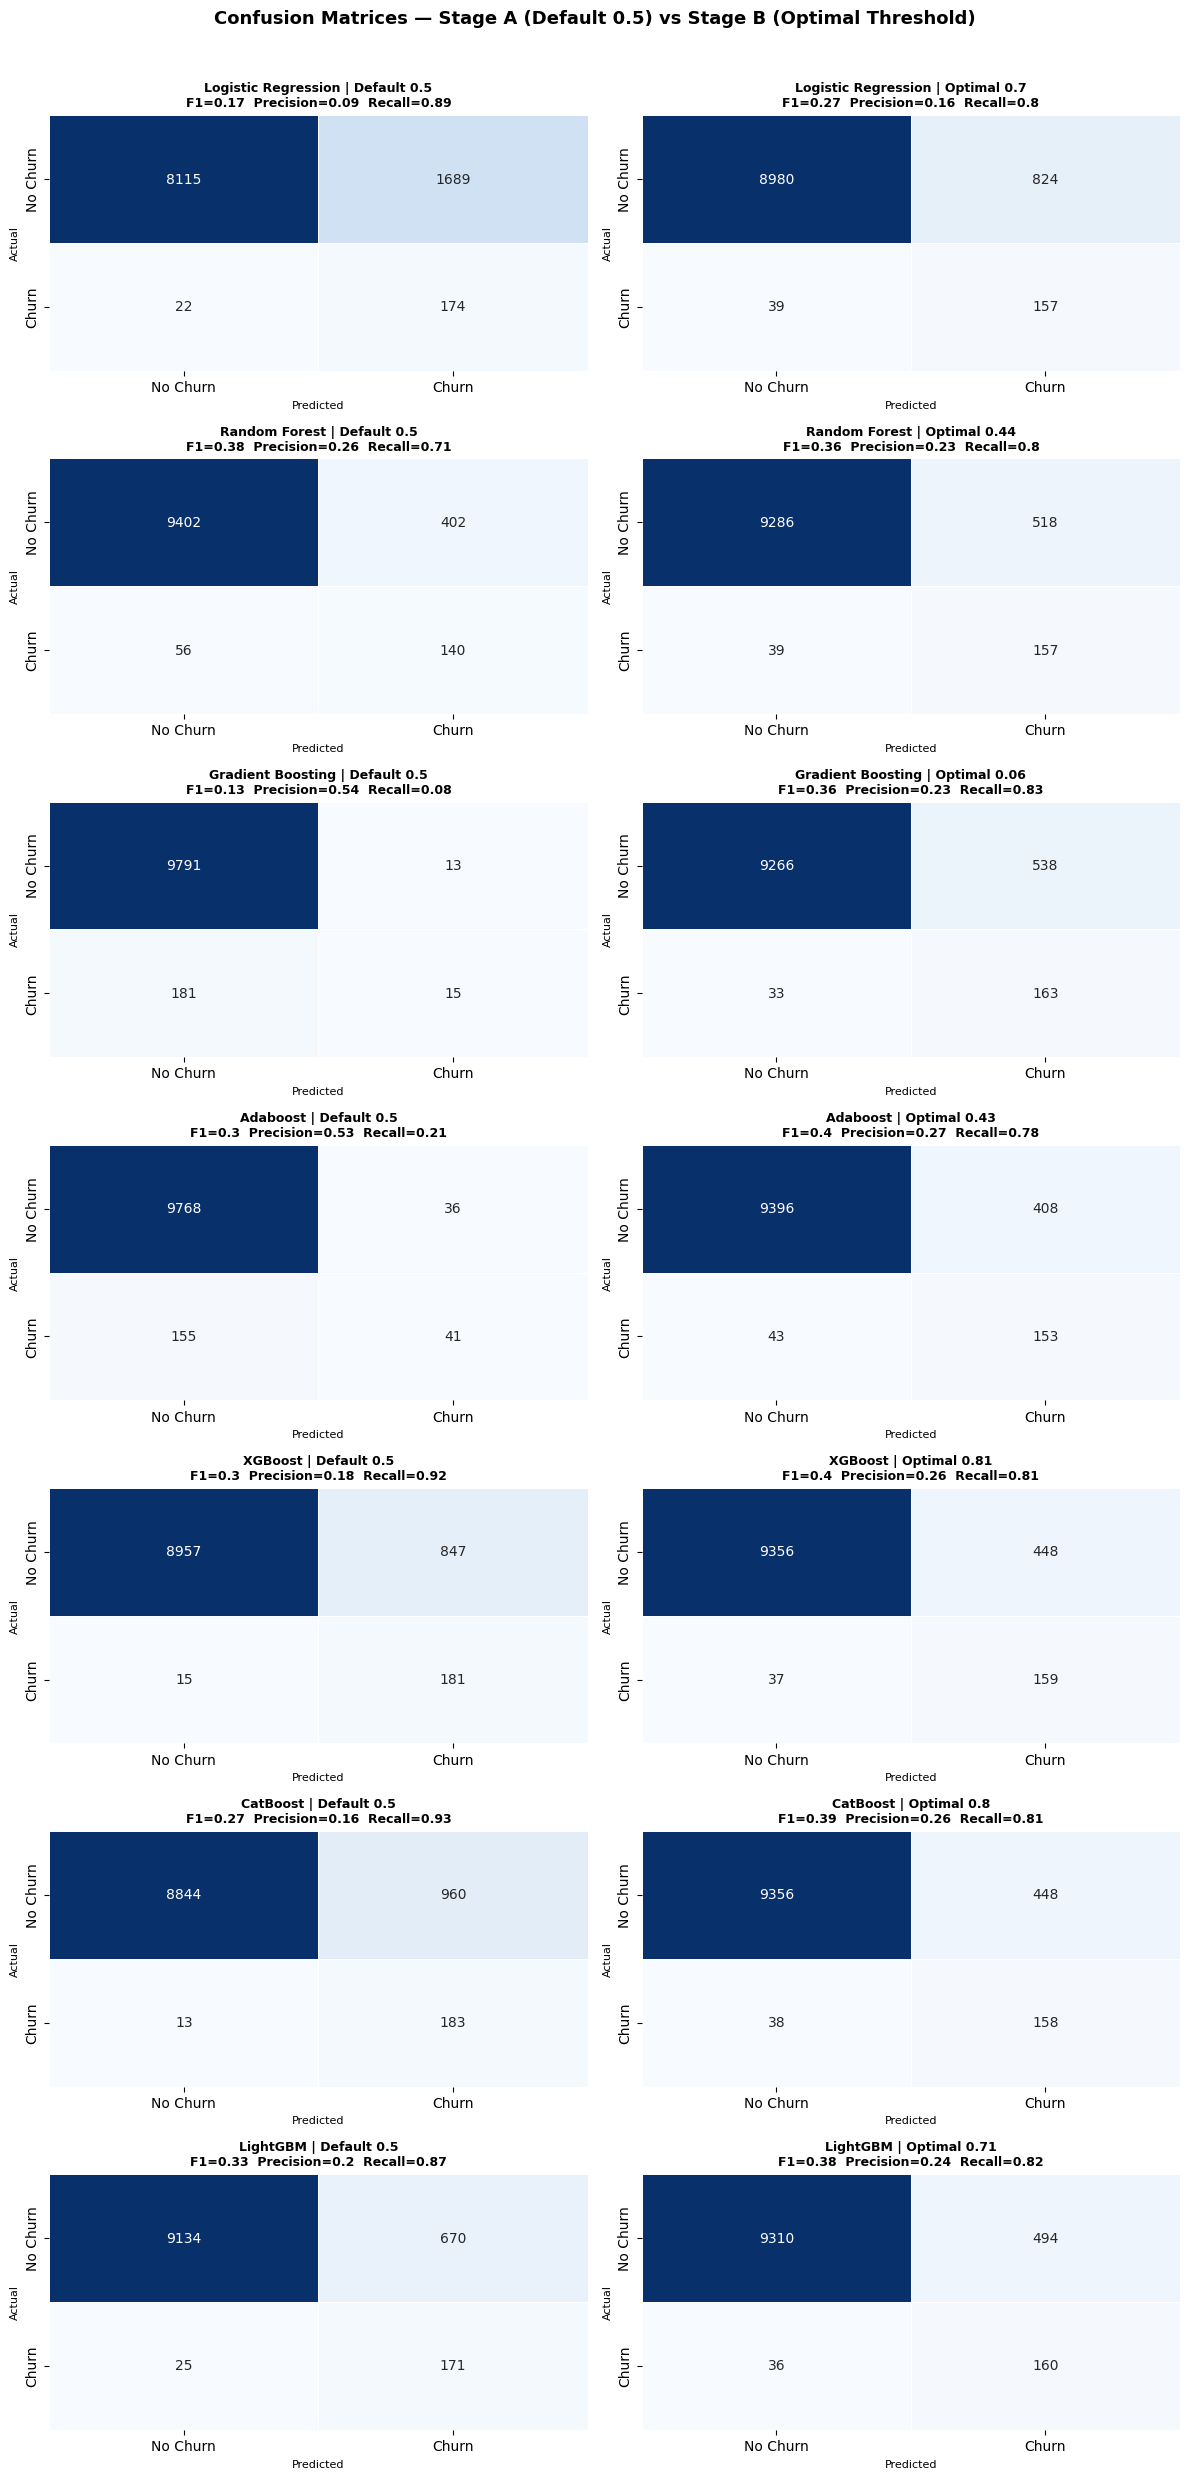

In [65]:
# ─────────────────────────────────────────────────────────────
# 6. CONFUSION MATRICES — STAGE A & B
# ─────────────────────────────────────────────────────────────
n_models = len(stage_a_results)
fig, axes = plt.subplots(n_models, 2, figsize=(12, n_models * 3.5))
fig.suptitle(
    'Confusion Matrices — Stage A (Default 0.5) vs Stage B (Optimal Threshold)',
    fontsize=13, fontweight='bold', y=1.01
)
 
for i, (res_a, res_b) in enumerate(zip(stage_a_results, stage_b_results)):
    for j, (res, label) in enumerate([
        (res_a, 'Default 0.5'),
        (res_b, f"Optimal {res_b['threshold']}")
    ]):
        cm = confusion_matrix(y_test, res['y_pred'])
        sns.heatmap(
            cm, annot=True, fmt='d', cmap='Blues',
            ax=axes[i][j],
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'],
            cbar=False, linewidths=0.5
        )
        axes[i][j].set_title(
            f"{res['model']} | {label}\n"
            f"F1={res['f1']}  Precision={res['precision']}  Recall={res['recall']}",
            fontsize=9, fontweight='bold'
        )
        axes[i][j].set_xlabel('Predicted', fontsize=8)
        axes[i][j].set_ylabel('Actual', fontsize=8)
 
plt.tight_layout()
# plt.savefig('/mnt/user-data/outputs/confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

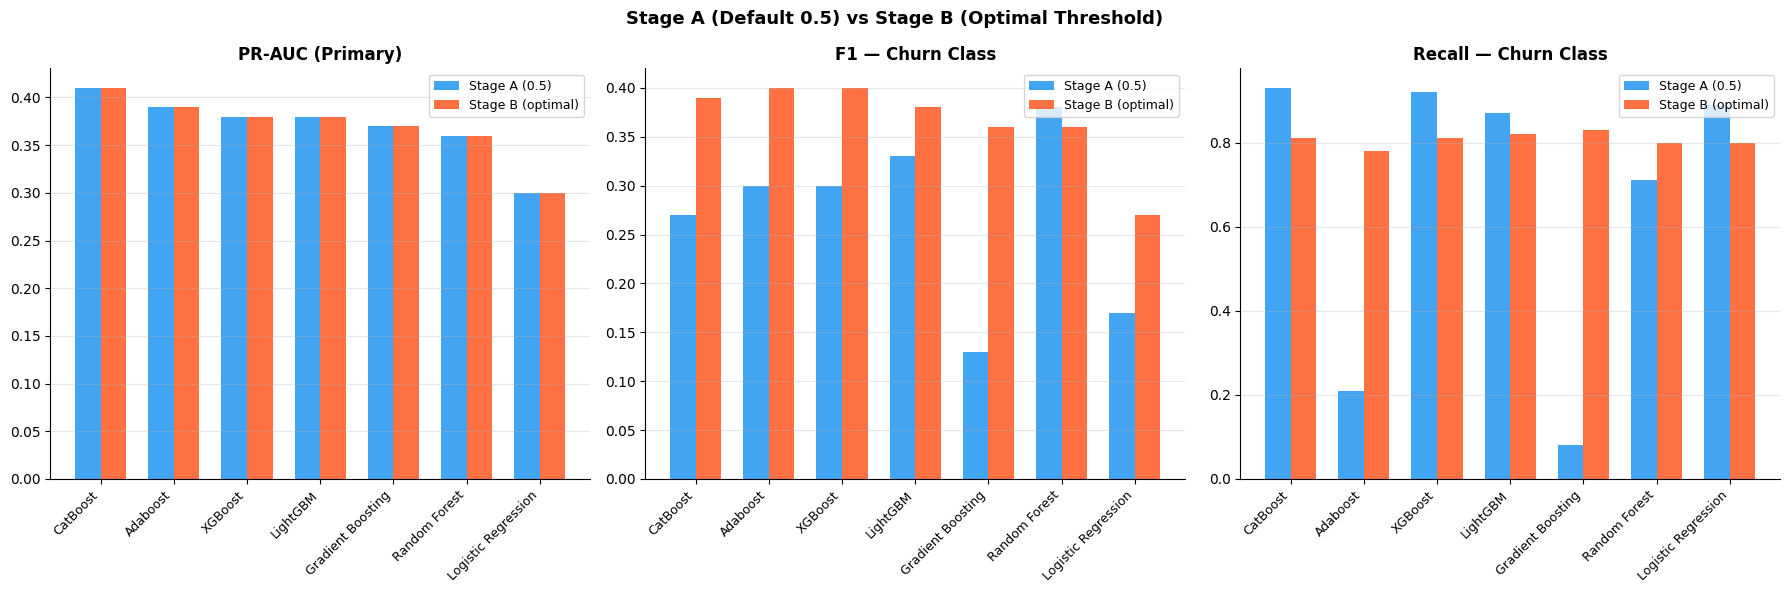

In [66]:
# ─────────────────────────────────────────────────────────────
# 7. METRIC COMPARISON — Stage A vs Stage B
# ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle(
    'Stage A (Default 0.5) vs Stage B (Optimal Threshold)',
    fontsize=13, fontweight='bold'
)
 
metrics_to_plot = ['pr_auc', 'f1', 'recall']
plot_titles     = ['PR-AUC (Primary)', 'F1 — Churn Class', 'Recall — Churn Class']
colors          = ['#2196F3', '#FF5722']
model_names     = stage_a_df['model'].tolist()
 
for ax, metric, title in zip(axes, metrics_to_plot, plot_titles):
    a_vals = stage_a_df.set_index('model').loc[model_names, metric].values
    b_vals = stage_b_df.set_index('model').loc[model_names, metric].values
    x, w   = np.arange(len(model_names)), 0.35
    ax.bar(x - w/2, a_vals, w, label='Stage A (0.5)',     color=colors[0], alpha=0.85)
    ax.bar(x + w/2, b_vals, w, label='Stage B (optimal)', color=colors[1], alpha=0.85)
    ax.set_title(title, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(model_names, rotation=45, ha='right', fontsize=9)
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)
    sns.despine(ax=ax)
 
plt.tight_layout()
# plt.savefig('/mnt/user-data/outputs/stage_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

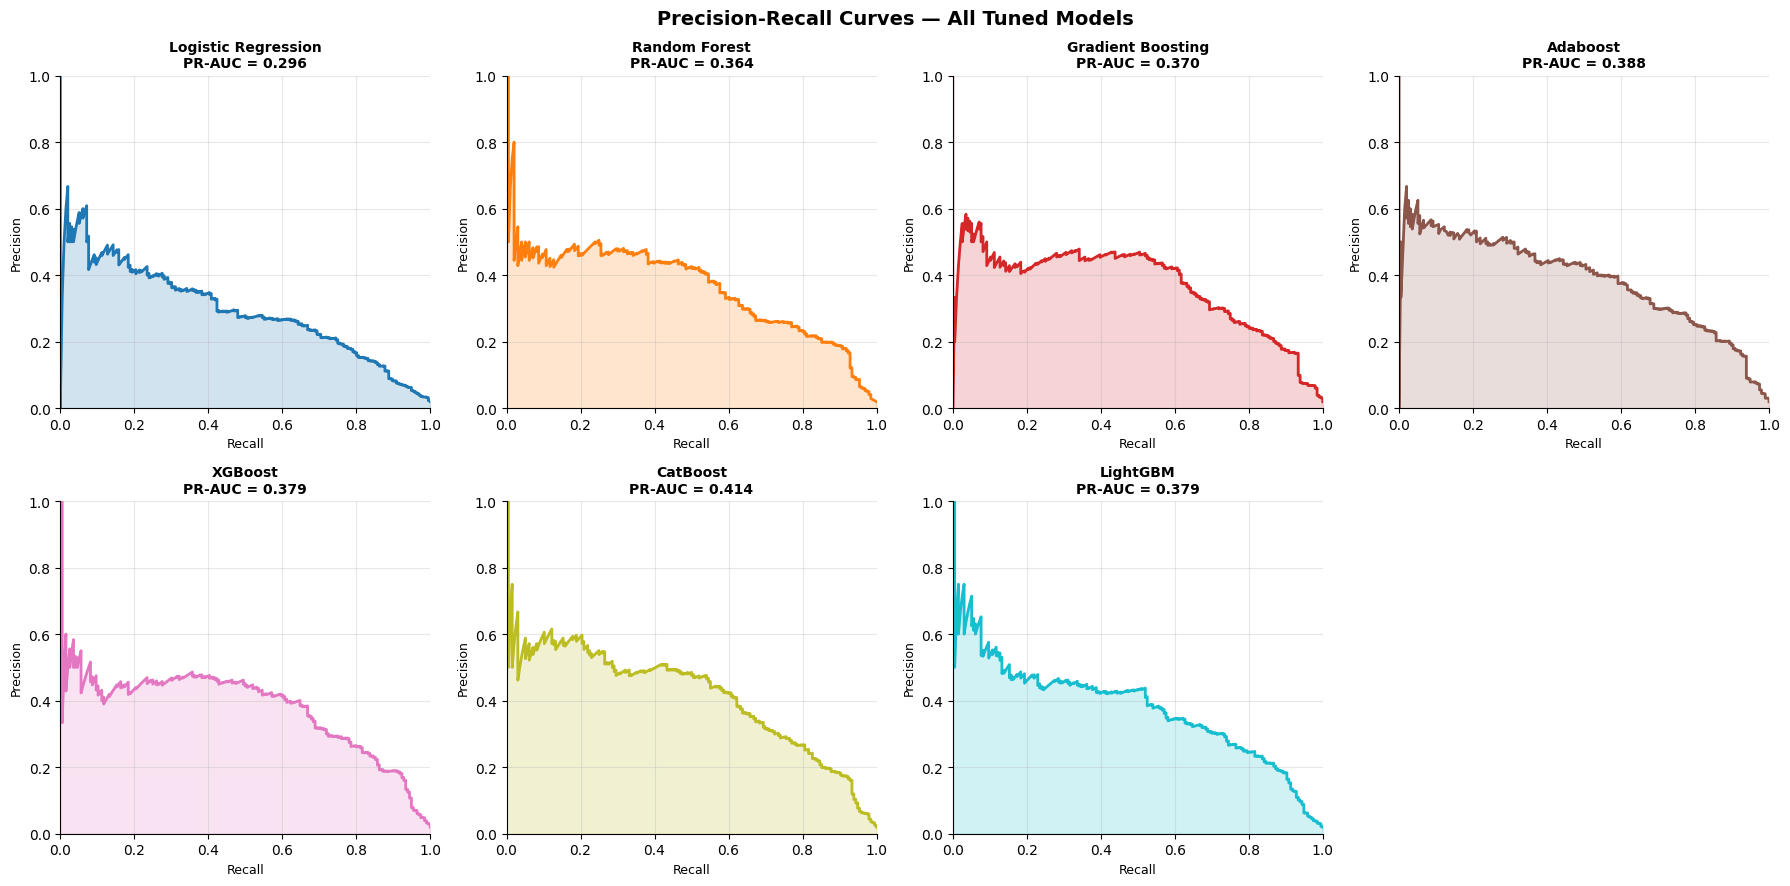

In [67]:
# ─────────────────────────────────────────────────────────────
# 8. PR CURVES — ALL TUNED MODELS
# ─────────────────────────────────────────────────────────────

n_models = len(best_models_tuned)
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()
fig.suptitle('Precision-Recall Curves — All Tuned Models', fontsize=14, fontweight='bold')

palette = plt.cm.tab10(np.linspace(0, 1, n_models))

for i, ((name, model), color) in enumerate(zip(best_models_tuned.items(), palette)):
    y_prob = model.predict_proba(X_test)[:, 1]
    precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_prob)
    pr_auc = average_precision_score(y_test, y_prob)

    axes[i].plot(recall_vals, precision_vals, color=color, linewidth=2)
    axes[i].fill_between(recall_vals, precision_vals, alpha=0.2, color=color)
    axes[i].set_title(f'{name}\nPR-AUC = {pr_auc:.3f}', fontsize=10, fontweight='bold')
    axes[i].set_xlabel('Recall', fontsize=9)
    axes[i].set_ylabel('Precision', fontsize=9)
    axes[i].set_xlim([0, 1])
    axes[i].set_ylim([0, 1])
    axes[i].grid(alpha=0.3)
    sns.despine(ax=axes[i])

# hide unused subplot if odd number of models
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

In [68]:
# ─────────────────────────────────────────────────────────────
# 9. FINAL BEST MODEL SELECTION
# ─────────────────────────────────────────────────────────────
best_a = stage_a_df.iloc[0]
best_b = stage_b_df.iloc[0]
 
if best_b['pr_auc'] >= best_a['pr_auc']:
    overall_best = best_b
    best_stage   = 'B (Optimal Threshold)'
else:
    overall_best = best_a
    best_stage   = 'A (Default Threshold 0.5)'
 
best_model_obj = best_models_tuned[overall_best['model']]
 
print("\n\n" + "=" * 60)
print("  FINAL BEST MODEL")
print("=" * 60)
print(f"\n  Model       : {overall_best['model']}")
print(f"  Stage       : {best_stage}")
print(f"  Threshold   : {overall_best['threshold']}")
print(f"\n  PR-AUC      : {overall_best['pr_auc']}")
print(f"  ROC-AUC     : {overall_best['roc_auc']}")
print(f"  F1 (Churn)  : {overall_best['f1']}")
print(f"  Precision   : {overall_best['precision']}")
print(f"  Recall      : {overall_best['recall']}")
print(f"\n  Best Hyperparameters:")
for param, value in best_params_all[overall_best['model']].items():
    print(f"    {param:<25} : {value}")



  FINAL BEST MODEL

  Model       : CatBoost
  Stage       : B (Optimal Threshold)
  Threshold   : 0.8

  PR-AUC      : 0.41
  ROC-AUC     : 0.96
  F1 (Churn)  : 0.39
  Precision   : 0.26
  Recall      : 0.81

  Best Hyperparameters:
    learning_rate             : 0.01
    l2_leaf_reg               : 1
    iterations                : 200
    depth                     : 4
    bagging_temperature       : 1


### Model Explainability using SHAP

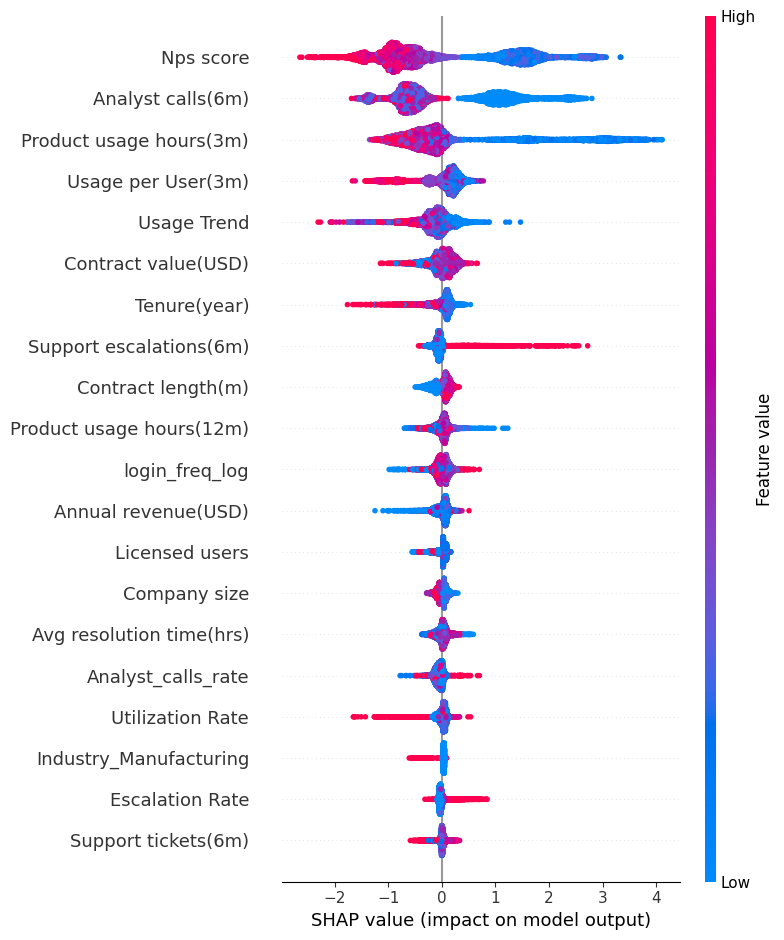

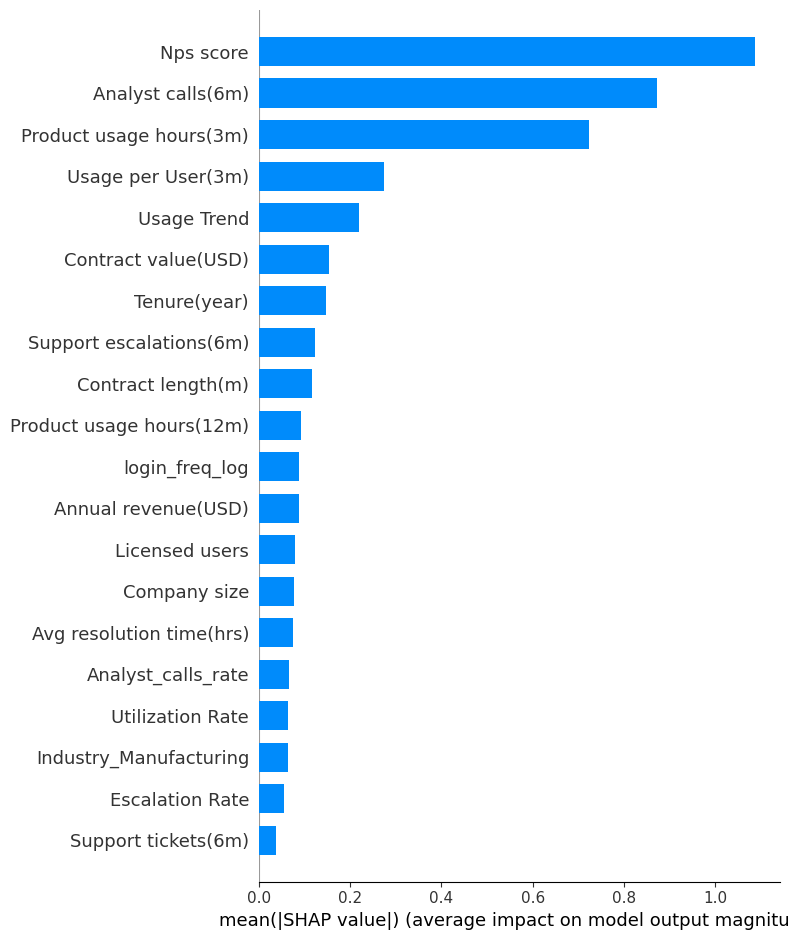

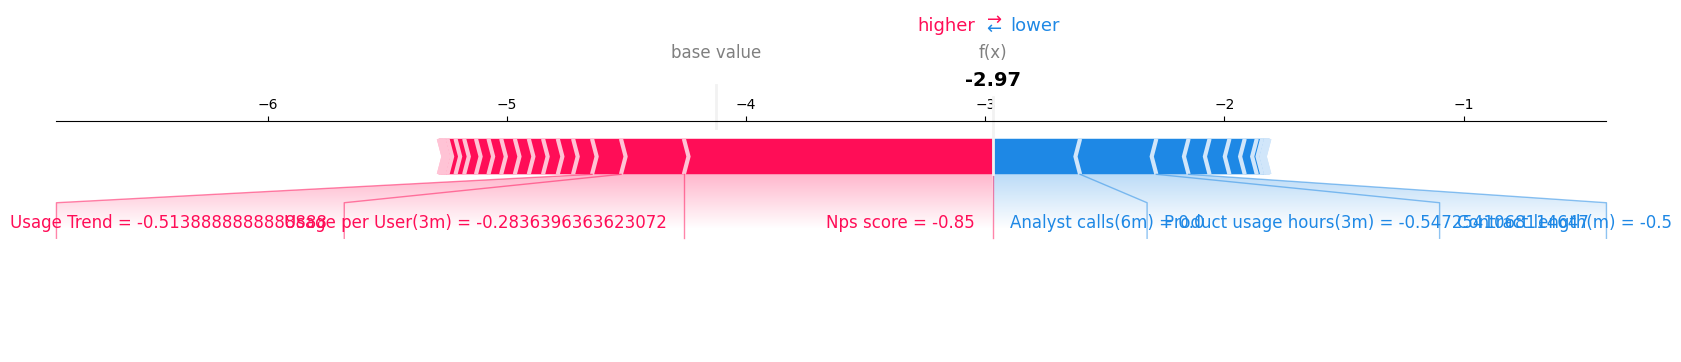

In [70]:
explainer=shap.TreeExplainer(model)
shap_values=explainer.shap_values(X_test)

shap.summary_plot(shap_values,X_test)
shap.summary_plot(shap_values,X_test,plot_type='bar')

i = 0
shap.force_plot(explainer.expected_value, shap_values[i], X_test.iloc[i], matplotlib=True)

In [71]:
def get_prob(model, X):
    # Case 1: model has predict_proba
    if hasattr(model, "predict_proba"):
        prob = model.predict_proba(X)
        
        # If 2D → take positive class
        if len(prob.shape) == 2:
            return prob[:, 1]
        return prob
    
    # Case 2: fallback (e.g., SVC without probability)
    elif hasattr(model, "decision_function"):
        return model.decision_function(X)
    
    else:
        raise ValueError("Model does not support probability prediction")

In [72]:
df = X_test.copy()
df['y_true'] = y_test.values
df['churn_prob'] = get_prob(model, X_test)

# Sort by risk
df = df.sort_values('churn_prob', ascending=False)

# Cumulative metrics
df['cum_churn'] = df['y_true'].cumsum()
total_churn = df['y_true'].sum()

df['cum_perc_churn'] = df['cum_churn'] / total_churn
df['cum_perc_users'] = (np.arange(1, len(df)+1)) / len(df)

# Key checkpoints
for pct in [0.1, 0.2, 0.3, 0.5]:
    churn_capture = df[df['cum_perc_users'] <= pct]['y_true'].sum() / total_churn
    print(f"Top {int(pct*100)}% users capture {churn_capture:.2%} churners")

Top 10% users capture 90.31% churners
Top 20% users capture 94.39% churners
Top 30% users capture 95.41% churners
Top 50% users capture 97.96% churners
